# Bodrum Hotel & Destination Intelligence
## 07 - Resmî Otel Özellikleri Analizi

Bu notebook, `06_hotel_attributes_match_audit.ipynb` aşamasında **yüksek güvenle** eşleştirilen
resmî tesis özelliklerini müşteri puanı, yorum hacmi, tek tarihli fiyat snapshot'ı ve destinasyon
bağlamıyla ilişkilendirir.

Her bölüm şu akışı izler: **Soru → İstatistik → Grafik → Bulgu → Sınırlılık**. Analiz yalnızca
ilgili değişkeni bulunan kayıtlarda yapılır; örneklem büyüklükleri gösterilir ve hiçbir ilişki
nedensellik olarak yorumlanmaz. Resmî yıldız sınıfı hizmet kalitesinin tamamını, Google puanı ise
müşteri deneyiminin tamamını ölçmez.

Bu notebookta kümeleme, tahmin modeli, anomali modeli, öneri sistemi veya NLP yapılmaz. Geçici
`hotel_size_group` ve `beds_per_room` özellikleri ana veri setine yazılmaz.


### 1. Kurulum ve veri kapsamı

Girdi `data/processed/hotels_enriched.csv` dosyasıdır. Dosya yoksa veya zorunlu kolonlar eksikse
analiz durur; sahte veri üretilmez. Ana 192 otellik evren ile yüksek güvenli resmî eşleşme
örneklemi birbirinden ayrılır.


In [1]:
from pathlib import Path
import hashlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from bodrum_intelligence.hotel_attributes_analysis import (
    SIZE_LABELS,
    assign_size_groups,
    correlation_results,
    correlation_table,
    coverage_summary,
    destination_capacity,
    interesting_cases,
    kruskal_star_rating_test,
    official_analysis_sample,
    price_premiums,
    size_summary,
    star_summary,
    type_summary,
)

ENRICHED_PATH = PROJECT_ROOT / "data" / "processed" / "hotels_enriched.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "hotel_attributes"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

assert ENRICHED_PATH.exists(), f"Zenginleştirilmiş veri bulunamadı: {ENRICHED_PATH}"
input_hash_before = hashlib.sha256(ENRICHED_PATH.read_bytes()).hexdigest()

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

df = pd.read_csv(ENRICHED_PATH, dtype={"phone": "string"})
official_df = official_analysis_sample(df)

assert len(df) == 192, f"Beklenen 192 ana otel yerine {len(df)} satır bulundu."
assert df["hotel_id"].nunique() == 192, "hotel_id benzersizliği bozulmuş."
print(f"Ana evren: {len(df)} otel")
print(f"Yüksek güvenli resmî eşleşme örneklemi: {len(official_df)} otel")


Ana evren: 192 otel
Yüksek güvenli resmî eşleşme örneklemi: 52 otel


In [2]:
PRIMARY = "#2F6B7C"
SECONDARY = "#4C956C"
ACCENT = "#C1666B"
HIGHLIGHT = "#D9A404"
NEUTRAL = "#7A7A7A"


def save_fig(fig, filename):
    fig.tight_layout()
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return path


def grouped_boxplot(frame, group_col, value_col, order, title, ylabel, filename, color=PRIMARY):
    data, labels = [], []
    for group in order:
        values = pd.to_numeric(
            frame.loc[frame[group_col].eq(group), value_col], errors="coerce"
        ).dropna()
        if len(values):
            data.append(values.to_numpy())
            labels.append(f"{group}\n(n={len(values)})")
    fig, ax = plt.subplots(figsize=(8.5, 5))
    box = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=True)
    for patch in box["boxes"]:
        patch.set(facecolor=color, alpha=0.42)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)
    save_fig(fig, filename)


def scatter_with_note(frame, x, y, title, xlabel, ylabel, filename, method_label="Pearson + Spearman"):
    pair = frame[[x, y]].apply(pd.to_numeric, errors="coerce").dropna()
    fig, ax = plt.subplots(figsize=(8, 5.3))
    ax.scatter(pair[x], pair[y], color=PRIMARY, alpha=0.70, s=42, edgecolor="white", linewidth=0.5)
    if len(pair) >= 2 and pair[x].nunique() > 1:
        slope, intercept = np.polyfit(pair[x], pair[y], 1)
        x_line = np.linspace(pair[x].min(), pair[x].max(), 80)
        ax.plot(x_line, slope * x_line + intercept, color=ACCENT, linestyle="--", linewidth=2)
    pearson = pair[x].corr(pair[y], method="pearson") if len(pair) >= 3 else np.nan
    spearman = pair[x].corr(pair[y], method="spearman") if len(pair) >= 3 else np.nan
    ax.text(
        0.03, 0.97,
        f"{method_label}\nPearson r={pearson:.2f}\nSpearman ρ={spearman:.2f}\nn={len(pair)}",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor=NEUTRAL),
    )
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.grid(alpha=0.2)
    save_fig(fig, filename)


def annotated_area_scatter(frame, x, y, title, xlabel, ylabel, filename):
    valid = frame.dropna(subset=[x, y])
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(valid[x], valid[y], s=70, color=PRIMARY, alpha=0.8)
    for row in valid.itertuples():
        ax.annotate(row.area, (getattr(row, x), getattr(row, y)), xytext=(5, 4),
                    textcoords="offset points", fontsize=8)
    rho = valid[x].corr(valid[y], method="spearman") if len(valid) >= 3 else np.nan
    ax.text(0.03, 0.97, f"Spearman ρ={rho:.2f}\nn={len(valid)} destinasyon",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor=NEUTRAL))
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.grid(alpha=0.2)
    save_fig(fig, filename)


In [3]:
coverage = coverage_summary(df)
display(coverage)


,metric,hotel_count,coverage_pct_of_192
0,total_hotels,192,100.000
1,high_confidence_official_match,52,27.100
2,verified_star_available,51,26.600
3,room_count_available,52,27.100
4,bed_count_available,52,27.100
5,official_type_available,52,27.100
6,price_snapshot_available,168,87.500


In [4]:
coverage_lookup = coverage.set_index("metric")
display(Markdown(
    f"**Bulgu:** 192 otelin {int(coverage_lookup.loc['high_confidence_official_match', 'hotel_count'])}'si "
    f"(%{coverage_lookup.loc['high_confidence_official_match', 'coverage_pct_of_192']:.1f}) yüksek güvenli "
    f"resmî eşleşmeye sahiptir. Doğrulanmış yıldız kapsamı "
    f"%{coverage_lookup.loc['verified_star_available', 'coverage_pct_of_192']:.1f}; oda ve yatak kapsamları "
    f"sırasıyla %{coverage_lookup.loc['room_count_available', 'coverage_pct_of_192']:.1f} ve "
    f"%{coverage_lookup.loc['bed_count_available', 'coverage_pct_of_192']:.1f}'dir. Sonraki tüm resmî özellik "
    f"karşılaştırmaları bu sınırlı ama güvenilir örneklem üzerinde yapılır."
))


**Bulgu:** 192 otelin 52'si (%27.1) yüksek güvenli resmî eşleşmeye sahiptir. Doğrulanmış yıldız kapsamı %26.6; oda ve yatak kapsamları sırasıyla %27.1 ve %27.1'dir. Sonraki tüm resmî özellik karşılaştırmaları bu sınırlı ama güvenilir örneklem üzerinde yapılır.

### 2. Doğrulanmış yıldız dağılımı

**Soru:** Yüksek güvenli eşleşme örnekleminde resmî yıldız sınıfları nasıl dağılıyor ve her grubun
rating, yorum ve fiyat özeti nedir?


,star,hotel_count,share_pct,avg_google_rating,median_google_rating,rating_std,rating_min,rating_max,median_review_count,price_n,median_price_snapshot,mean_price_snapshot,price_q25,price_q75,median_weighted_rating,median_rating_gap_from_area,median_price_ratio_to_area
0,2.000,3,5.900,4.367,4.500,0.416,3.900,4.700,221.000,2,105.500,105.500,92.250,118.750,4.393,0.200,0.709
1,3.000,10,19.600,4.360,4.300,0.212,4.000,4.700,445.500,9,125.000,130.778,109.000,145.000,4.339,-0.000,0.765
2,4.000,17,33.300,4.265,4.400,0.320,3.700,4.900,"1,340.000",15,216.000,400.800,143.500,282.500,4.380,0.000,1.080
3,5.000,21,41.200,4.481,4.600,0.277,3.900,4.800,"1,575.000",19,304.000,586.368,208.000,481.500,4.460,0.150,1.883


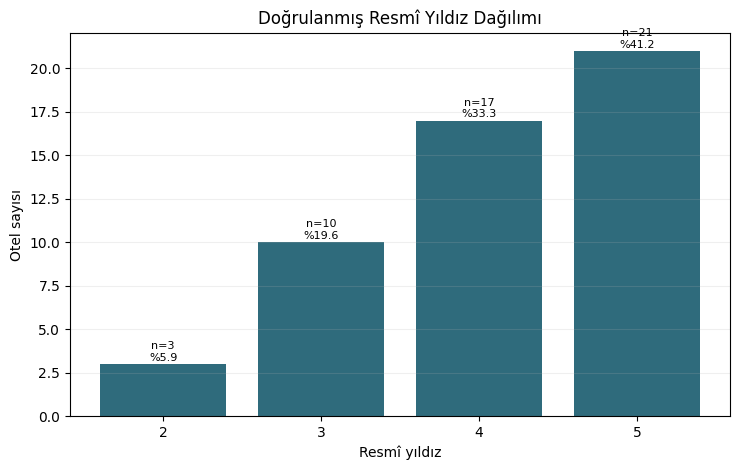

PosixPath('/Users/nihatkutukoglu/Downloads/bodrum-otel/reports/figures/hotel_attributes/star_distribution.png')

In [5]:
stars = star_summary(official_df)
display(stars)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.bar(stars["star"].astype(int).astype(str), stars["hotel_count"], color=PRIMARY)
for x, row in enumerate(stars.itertuples()):
    ax.text(x, row.hotel_count + 0.2, f"n={row.hotel_count}\n%{row.share_pct:.1f}", ha="center", fontsize=8)
ax.set(title="Doğrulanmış Resmî Yıldız Dağılımı", xlabel="Resmî yıldız", ylabel="Otel sayısı")
ax.grid(axis="y", alpha=0.2)
save_fig(fig, "star_distribution.png")


In [6]:
largest_star = stars.sort_values(["hotel_count", "star"], ascending=[False, False]).iloc[0]
display(Markdown(
    f"**Bulgu:** En geniş grup {int(largest_star['star'])} yıldızlı tesislerdir "
    f"(n={int(largest_star['hotel_count'])}, doğrulanmış yıldızlı örneklemin "
    f"%{largest_star['share_pct']:.1f}'i). Grafikte 1 yıldızlı grup görünmüyorsa bu, örneklemde "
    f"doğrulanmış 1 yıldızlı kayıt bulunmadığı anlamına gelir; sıfır gözlem uydurulmamıştır."
))


**Bulgu:** En geniş grup 5 yıldızlı tesislerdir (n=21, doğrulanmış yıldızlı örneklemin %41.2'i). Grafikte 1 yıldızlı grup görünmüyorsa bu, örneklemde doğrulanmış 1 yıldızlı kayıt bulunmadığı anlamına gelir; sıfır gözlem uydurulmamıştır.

### 3. Resmî yıldız sınıfı ↔ Google müşteri puanı

**Soru:** Bu örneklemde resmî yıldız sınıfı yükseldikçe Google puanı da yükseliyor mu? Yıldız
ordinal olduğu için temel ilişki ölçüsü Spearman korelasyonudur. Grup dağılımları küçük olduğu için
kutu grafiği tek tek noktalarla birlikte okunur.


,star,hotel_count,avg_google_rating,median_google_rating,rating_std,rating_min,rating_max
0,2.000,3,4.367,4.500,0.416,3.900,4.700
1,3.000,10,4.360,4.300,0.212,4.000,4.700
2,4.000,17,4.265,4.400,0.320,3.700,4.900
3,5.000,21,4.481,4.600,0.277,3.900,4.800


,analysis,method,n,coefficient,p_value
0,official_star_rating_verified vs google_rating,spearman,51,0.238,0.092


/var/folders/35/w7v4jvv930z1wthrlzsp49th0000gn/T/ipykernel_52183/555081817.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(box_data, labels=[f"{int(s)} yıldız\n(n={len(v)})" for s, v in zip(order, box_data)], patch_artist=True)


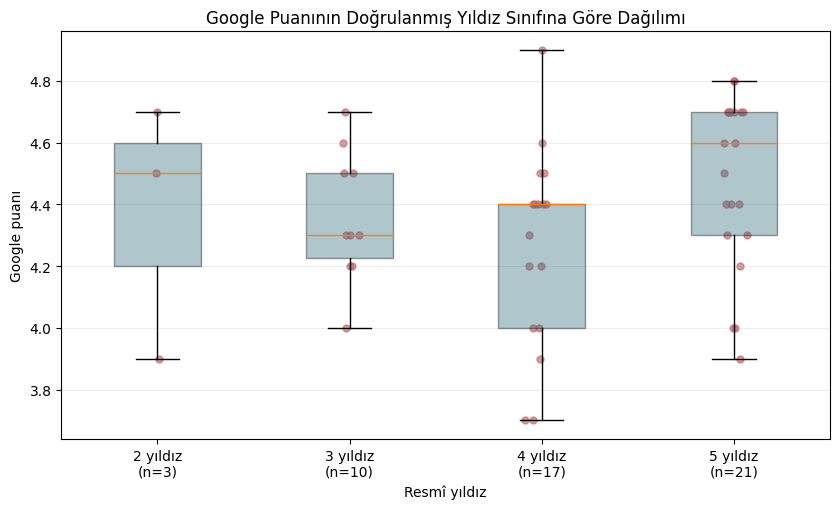

PosixPath('/Users/nihatkutukoglu/Downloads/bodrum-otel/reports/figures/hotel_attributes/rating_by_star.png')

In [7]:
star_rating_corr = correlation_table(correlation_results(
    official_df, "official_star_rating_verified", "google_rating",
    "official_star_rating_verified vs google_rating", methods=("spearman",)
))
display(stars[["star", "hotel_count", "avg_google_rating", "median_google_rating", "rating_std", "rating_min", "rating_max"]])
display(star_rating_corr)

valid_star_rating = official_df.dropna(subset=["official_star_rating_verified", "google_rating"])
order = sorted(valid_star_rating["official_star_rating_verified"].unique())
fig, ax = plt.subplots(figsize=(8.5, 5.2))
box_data = [valid_star_rating.loc[valid_star_rating["official_star_rating_verified"].eq(s), "google_rating"] for s in order]
box = ax.boxplot(box_data, labels=[f"{int(s)} yıldız\n(n={len(v)})" for s, v in zip(order, box_data)], patch_artist=True)
for patch in box["boxes"]:
    patch.set(facecolor=PRIMARY, alpha=0.38)
rng = np.random.default_rng(7)
for pos, values in enumerate(box_data, start=1):
    ax.scatter(rng.normal(pos, 0.035, len(values)), values, color=ACCENT, alpha=0.65, s=25)
ax.set(title="Google Puanının Doğrulanmış Yıldız Sınıfına Göre Dağılımı", xlabel="Resmî yıldız", ylabel="Google puanı")
ax.grid(axis="y", alpha=0.22)
save_fig(fig, "rating_by_star.png")


In [8]:
star_rho = star_rating_corr.loc[0, "coefficient"]
star_p = star_rating_corr.loc[0, "p_value"]
median_text = ", ".join(
    f"{int(row.star)} yıldız: {row.median_google_rating:.2f} (n={int(row.hotel_count)})"
    for row in stars.itertuples()
)
display(Markdown(
    f"**Bulgu:** Grup medyanları {median_text}. Yıldız ile Google puanı arasındaki Spearman "
    f"ilişkisi ρ={star_rho:.2f} (p={star_p:.3f}, n={int(star_rating_corr.loc[0, 'n'])}). "
    f"Bu sonuç örneklem içi birlikteliği gösterir; hizmet kalitesine ilişkin nedensel bir etkiyi göstermez."
))


**Bulgu:** Grup medyanları 2 yıldız: 4.50 (n=3), 3 yıldız: 4.30 (n=10), 4 yıldız: 4.40 (n=17), 5 yıldız: 4.60 (n=21). Yıldız ile Google puanı arasındaki Spearman ilişkisi ρ=0.24 (p=0.092, n=51). Bu sonuç örneklem içi birlikteliği gösterir; hizmet kalitesine ilişkin nedensel bir etkiyi göstermez.

### 4. Yıldız–müşteri algısı açısından ilginç vakalar

Normatif “iyi/kötü otel” etiketleri kullanılmaz. Aşağıdaki listeler yalnızca aynı örneklem içindeki
göreli uçları görünür kılar; düşük yorum hacminde ham puan daha oynak olabileceği için yorum sayısı da
sunulur.


In [9]:
case_columns = [
    "hotel_name", "area", "official_star_rating_verified", "google_rating",
    "weighted_google_rating", "google_review_count", "official_room_count",
    "search_price_usd_snapshot",
]
five_star_lower = (
    official_df.loc[official_df["official_star_rating_verified"].eq(5), case_columns]
    .sort_values(["google_rating", "google_review_count"], ascending=[True, False]).head(10)
)
lower_star_higher = (
    official_df.loc[official_df["official_star_rating_verified"].le(3), case_columns]
    .sort_values(["google_rating", "google_review_count"], ascending=[False, False]).head(10)
)
print("5 yıldızlı ancak örneklem içinde görece düşük müşteri puanlı tesisler")
display(five_star_lower)
print("3 yıldız ve altı olup örneklem içinde görece yüksek müşteri puanlı tesisler")
display(lower_star_higher)


5 yıldızlı ancak örneklem içinde görece düşük müşteri puanlı tesisler


,hotel_name,area,official_star_rating_verified,google_rating,weighted_google_rating,google_review_count,official_room_count,search_price_usd_snapshot
160,MyElla Hotel Resort & Spa,Turgutreis,5.000,3.900,3.964,2926,258.000,125.000
112,Kadıkale Resort,Kadıkalesi,5.000,4.000,4.065,2121,197.000,NaN
162,Sundance Resort,Turgutreis,5.000,4.000,4.094,1344,183.000,66.000
71,VERY CHIC BODRUM,Gümbet,5.000,4.200,4.236,1670,149.000,241.000
32,Ramada Resort by Wyndham Bodrum,Bitez,5.000,4.300,4.322,870,129.000,206.000
185,Sirene Luxury Hotel Bodrum,Yalıkavak,5.000,4.300,4.326,673,109.000,388.000
149,Samara Hotel,Torba,5.000,4.400,4.394,2488,339.000,284.000
188,The Bodrum EDITION,Yalıkavak,5.000,4.400,4.389,1016,108.000,841.000
22,Doria Hotel Bodrum,Bitez,5.000,4.400,4.386,774,92.000,171.000
20,"Caresse, a Luxury Collection Resort & Spa, Bodrum",Bitez,5.000,4.500,4.454,904,77.000,"1,654.000"


3 yıldız ve altı olup örneklem içinde görece yüksek müşteri puanlı tesisler


,hotel_name,area,official_star_rating_verified,google_rating,weighted_google_rating,google_review_count,official_room_count,search_price_usd_snapshot
99,Villa Rustica Hotel,Gündoğan,3.000,4.700,4.479,243,30.000,145.000
47,Babana Hotel,Göltürkbükü,2.000,4.700,4.472,221,36.000,132.000
35,Bodrium Hotel & SPA,Bodrum Merkez,3.000,4.600,4.530,1102,50.000,151.000
135,Zest Exclusive Hotel and Spa,Ortakent-Yahşi,3.000,4.500,4.432,467,24.000,130.000
7,LA BREZZA SUITE &HOTEL,Akyarlar,3.000,4.500,4.429,424,31.000,121.000
120,Eskiyalı Otel,Ortakent-Yahşi,2.000,4.500,4.393,130,44.000,NaN
144,Moyo Luxury Hotel & Beach,Torba,3.000,4.300,4.335,370,48.000,NaN
91,Liona Hotel,Gündoğan,3.000,4.300,4.338,307,44.000,109.000
70,Tropicana Beach Hotel,Gümbet,3.000,4.300,4.340,281,42.000,87.000
56,Selvi Bodrum,Göltürkbükü,3.000,4.200,4.273,584,20.000,207.000


### 5. Resmî yıldız sınıfı ↔ tek tarihli fiyat snapshot'ı

**Soru:** Resmî yıldız sınıfı fiyat snapshot'ıyla nasıl ilişkili? Fiyat yalnızca toplama anındaki
arama görünümüdür; sabit oda fiyatı, yıllık ortalama veya sezon geneli fiyat olarak yorumlanamaz.


,star,price_n,median_price_snapshot,mean_price_snapshot,price_q25,price_q75
0,2.000,2,105.500,105.500,92.250,118.750
1,3.000,9,125.000,130.778,109.000,145.000
2,4.000,15,216.000,400.800,143.500,282.500
3,5.000,19,304.000,586.368,208.000,481.500


/var/folders/35/w7v4jvv930z1wthrlzsp49th0000gn/T/ipykernel_52183/3711770437.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=True)


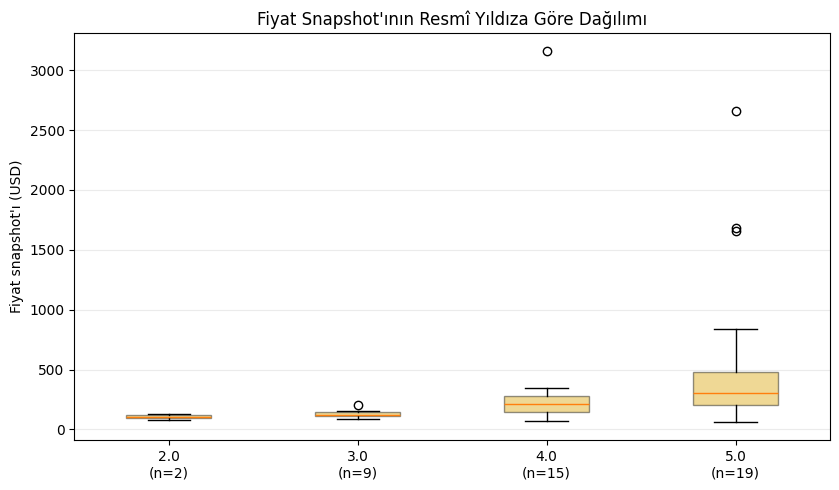

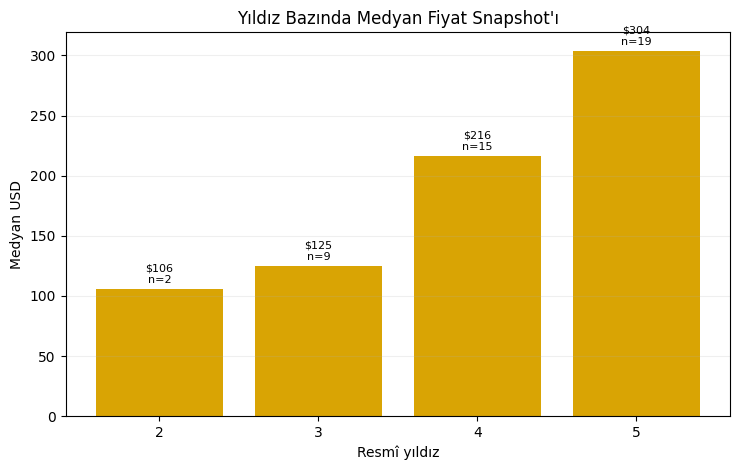

,comparison,higher_star,lower_star,higher_price_n,lower_price_n,higher_median_price,lower_median_price,median_price_premium_pct
0,5_star_vs_4_star,5,4,19,15,304.000,216.000,40.741
1,4_star_vs_3_star,4,3,15,9,216.000,125.000,72.800
2,3_star_vs_2_star,3,2,9,2,125.000,105.500,18.483


In [10]:
price_star_columns = ["star", "price_n", "median_price_snapshot", "mean_price_snapshot", "price_q25", "price_q75"]
display(stars[price_star_columns])
grouped_boxplot(
    official_df.dropna(subset=["search_price_usd_snapshot"]),
    "official_star_rating_verified", "search_price_usd_snapshot",
    sorted(stars["star"]), "Fiyat Snapshot'ının Resmî Yıldıza Göre Dağılımı",
    "Fiyat snapshot'ı (USD)", "price_by_star.png", color=HIGHLIGHT,
)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.bar(stars["star"].astype(int).astype(str), stars["median_price_snapshot"], color=HIGHLIGHT)
for x, row in enumerate(stars.itertuples()):
    ax.text(x, row.median_price_snapshot + 5, f"${row.median_price_snapshot:,.0f}\nn={row.price_n}", ha="center", fontsize=8)
ax.set(title="Yıldız Bazında Medyan Fiyat Snapshot'ı", xlabel="Resmî yıldız", ylabel="Medyan USD")
ax.grid(axis="y", alpha=0.2)
save_fig(fig, "median_price_by_star.png")

premiums = price_premiums(stars)
display(premiums)


In [11]:
premium_lines = []
for row in premiums.itertuples():
    premium_lines.append(
        f"{row.higher_star} yıldız / {row.lower_star} yıldız medyan farkı %{row.median_price_premium_pct:.1f} "
        f"(n={row.higher_price_n} ve n={row.lower_price_n})"
    )
display(Markdown(
    "**Bulgu:** " + "; ".join(premium_lines) + ". Bu oranlar küçük grup örneklemleri ve tek fiyat "
    "snapshot'ı nedeniyle keşifsel göstergelerdir."
))


**Bulgu:** 5 yıldız / 4 yıldız medyan farkı %40.7 (n=19 ve n=15); 4 yıldız / 3 yıldız medyan farkı %72.8 (n=15 ve n=9); 3 yıldız / 2 yıldız medyan farkı %18.5 (n=9 ve n=2). Bu oranlar küçük grup örneklemleri ve tek fiyat snapshot'ı nedeniyle keşifsel göstergelerdir.

### 6. Resmî oda sayısı dağılımı ve geçici tesis büyüklüğü

**Soru:** Eşleşen tesislerin kapasite dağılımı nedir? İstatistiksel uçlar silinmez. `Small`,
`Medium`, `Large` grupları oda sayısının üçte birlik yüzdeliklerinden türetilir; ana veriye yazılmaz.


,official_room_count
count,52.000
mean,120.154
std,108.831
min,12.000
q25,43.500
median,81.500
q75,166.250
max,540.000


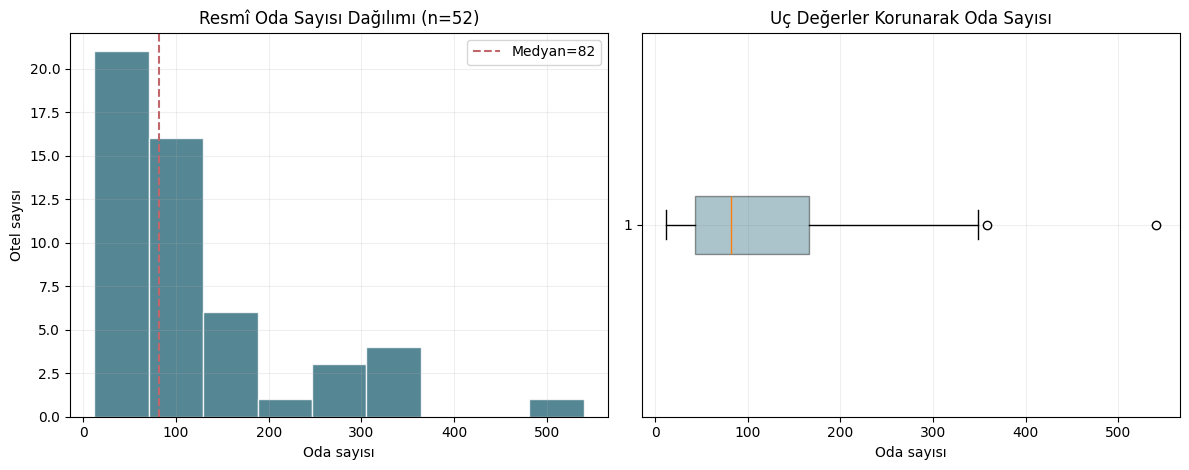

,q33,q67
0,50.000,116.000


,hotel_size_group,n,min_room_count,median_room_count,max_room_count,avg_google_rating,median_google_rating,median_review_count,median_price
0,Small,18,12.000,34.000,50.000,4.417,4.500,342.000,138.500
1,Medium,16,60.000,81.500,110.000,4.469,4.400,945.500,260.500
2,Large,18,116.000,190.000,540.000,4.267,4.300,"2,507.500",226.500


In [12]:
room_desc = official_df["official_room_count"].describe(percentiles=[0.25, 0.5, 0.75]).rename({"50%": "median", "25%": "q25", "75%": "q75"})
display(room_desc.to_frame("official_room_count"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
rooms = official_df["official_room_count"].dropna()
axes[0].hist(rooms, bins="auto", color=PRIMARY, alpha=0.82, edgecolor="white")
axes[0].axvline(rooms.median(), color=ACCENT, linestyle="--", label=f"Medyan={rooms.median():.0f}")
axes[0].set(title=f"Resmî Oda Sayısı Dağılımı (n={len(rooms)})", xlabel="Oda sayısı", ylabel="Otel sayısı")
axes[0].legend()
axes[1].boxplot(rooms, vert=False, patch_artist=True, boxprops=dict(facecolor=PRIMARY, alpha=0.4))
axes[1].set(title="Uç Değerler Korunarak Oda Sayısı", xlabel="Oda sayısı")
for ax in axes: ax.grid(alpha=0.2)
save_fig(fig, "room_count_distribution.png")

size_table, size_thresholds = size_summary(official_df)
official_df["hotel_size_group"], _ = assign_size_groups(official_df["official_room_count"])
display(pd.DataFrame([size_thresholds]))
display(size_table)


In [13]:
threshold_text = (
    f"q33={size_thresholds['q33']:.1f}, q67={size_thresholds['q67']:.1f} oda"
    if 'q33' in size_thresholds else f"medyan fallback={size_thresholds['median_fallback']:.1f} oda"
)
display(Markdown(
    f"**Bulgu:** Resmî oda sayısı medyanı {rooms.median():.0f}, IQR "
    f"{rooms.quantile(.25):.0f}–{rooms.quantile(.75):.0f}, aralık {rooms.min():.0f}–{rooms.max():.0f}'dır. "
    f"Boyut eşikleri gerçek dağılımdan türetilmiştir ({threshold_text}); uç değerler korunmuştur."
))


**Bulgu:** Resmî oda sayısı medyanı 82, IQR 44–166, aralık 12–540'dır. Boyut eşikleri gerçek dağılımdan türetilmiştir (q33=50.0, q67=116.0 oda); uç değerler korunmuştur.

### 7. Tesis büyüklüğü ↔ müşteri puanı

**Soru:** Daha büyük tesislerin müşteri puanları farklılaşıyor mu? Sürekli oda sayısı için Pearson
ve Spearman; açıklanabilir grup karşılaştırması için kutu grafiği kullanılır.


,analysis,method,n,coefficient,p_value
0,room_count vs google_rating,pearson,52,-0.056,0.693
1,room_count vs google_rating,spearman,52,-0.165,0.242


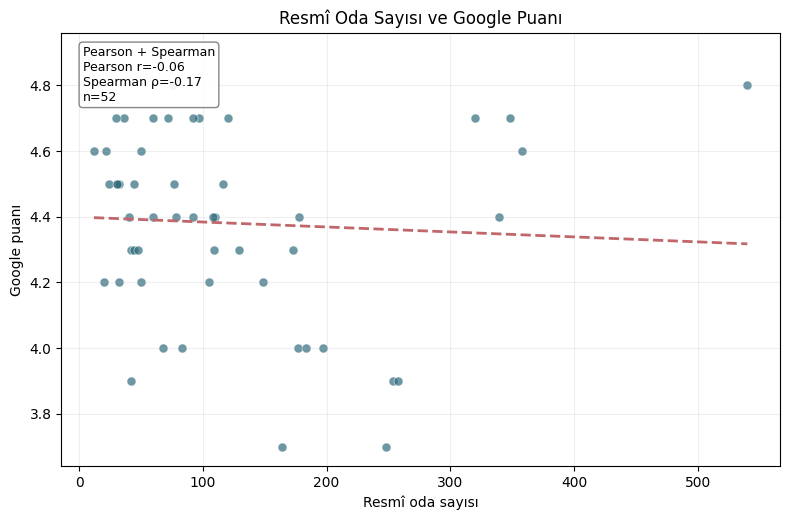

/var/folders/35/w7v4jvv930z1wthrlzsp49th0000gn/T/ipykernel_52183/3711770437.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=True)


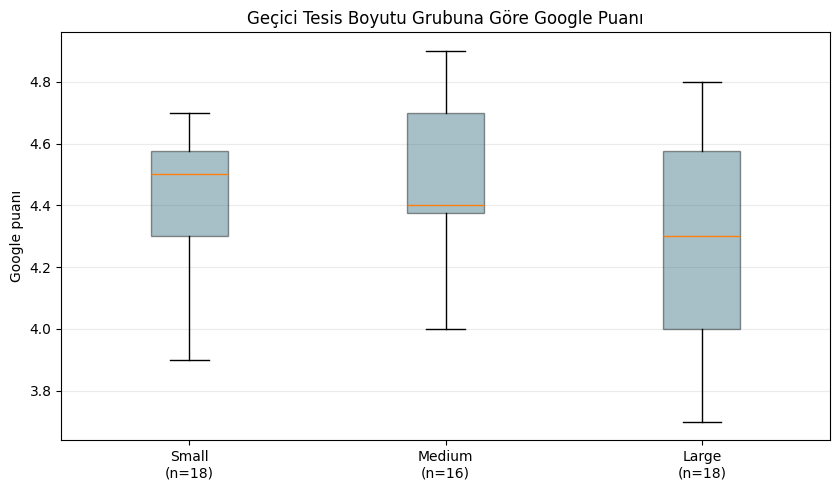

In [14]:
room_rating_corr = correlation_table(correlation_results(
    official_df, "official_room_count", "google_rating", "room_count vs google_rating"
))
display(room_rating_corr)
scatter_with_note(
    official_df, "official_room_count", "google_rating",
    "Resmî Oda Sayısı ve Google Puanı", "Resmî oda sayısı", "Google puanı",
    "room_count_vs_rating.png",
)
grouped_boxplot(
    official_df, "hotel_size_group", "google_rating", SIZE_LABELS,
    "Geçici Tesis Boyutu Grubuna Göre Google Puanı", "Google puanı", "rating_by_size.png",
)


In [15]:
room_rating_spearman = room_rating_corr.loc[room_rating_corr["method"].eq("spearman")].iloc[0]
display(Markdown(
    f"**Bulgu:** Oda sayısı ile Google puanı arasındaki Spearman ilişkisi "
    f"ρ={room_rating_spearman.coefficient:.2f} (p={room_rating_spearman.p_value:.3f}, "
    f"n={int(room_rating_spearman.n)}). Boyut grupları dağılımı özetler; farklılaşmanın nedeni hakkında "
    f"tek başına kanıt sunmaz."
))


**Bulgu:** Oda sayısı ile Google puanı arasındaki Spearman ilişkisi ρ=-0.17 (p=0.242, n=52). Boyut grupları dağılımı özetler; farklılaşmanın nedeni hakkında tek başına kanıt sunmaz.

### 8. Tesis büyüklüğü ↔ yorum hacmi

**Soru:** Büyük tesisler daha fazla Google yorumu topluyor mu? Yorum sayısı sağa çarpık olduğu için
ana görselde `log1p(google_review_count)` kullanılır; Spearman sıralama ilişkisi ham sayılarla aynıdır.


,analysis,method,n,coefficient,p_value
0,room_count vs google_review_count,spearman,52,0.859,0.000


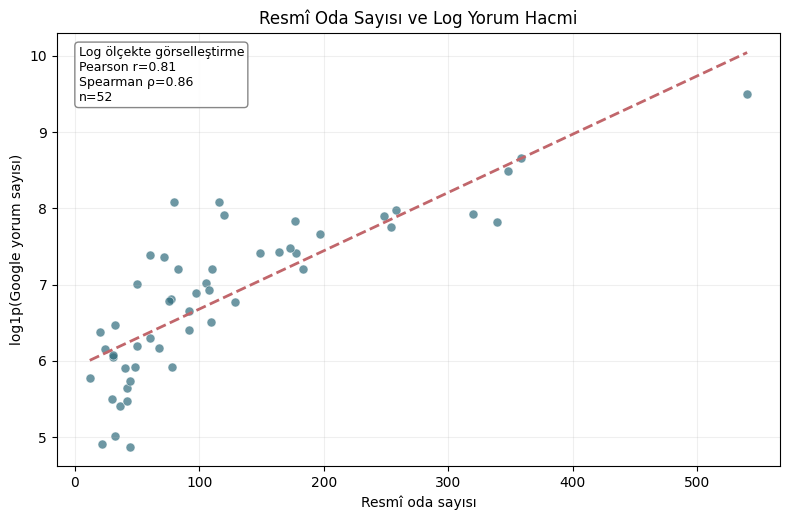

In [16]:
official_df["log_review_count"] = np.log1p(official_df["google_review_count"])
room_review_corr = correlation_table(correlation_results(
    official_df, "official_room_count", "google_review_count", "room_count vs google_review_count",
    methods=("spearman",)
))
display(room_review_corr)
scatter_with_note(
    official_df, "official_room_count", "log_review_count",
    "Resmî Oda Sayısı ve Log Yorum Hacmi", "Resmî oda sayısı", "log1p(Google yorum sayısı)",
    "room_count_vs_reviews.png", method_label="Log ölçekte görselleştirme",
)


In [17]:
room_review_spearman = room_review_corr.iloc[0]
display(Markdown(
    f"**Bulgu:** Oda sayısı ile yorum hacmi arasındaki Spearman ilişkisi "
    f"ρ={room_review_spearman.coefficient:.2f} (p={room_review_spearman.p_value:.3f}, "
    f"n={int(room_review_spearman.n)}). Yorum sayısı tesis yaşı, görünürlük ve platform davranışından da etkilenebilir."
))


**Bulgu:** Oda sayısı ile yorum hacmi arasındaki Spearman ilişkisi ρ=0.86 (p=0.000, n=52). Yorum sayısı tesis yaşı, görünürlük ve platform davranışından da etkilenebilir.

### 9. Tesis büyüklüğü ↔ fiyat snapshot'ı

**Soru:** Bu örneklemde daha fazla odalı tesisler daha pahalı görünüyor mu? Yalnızca fiyatı bulunan
kayıtlar kullanılır.


,analysis,method,n,coefficient,p_value
0,room_count vs price_snapshot,pearson,46,0.115,0.447
1,room_count vs price_snapshot,spearman,46,0.129,0.391


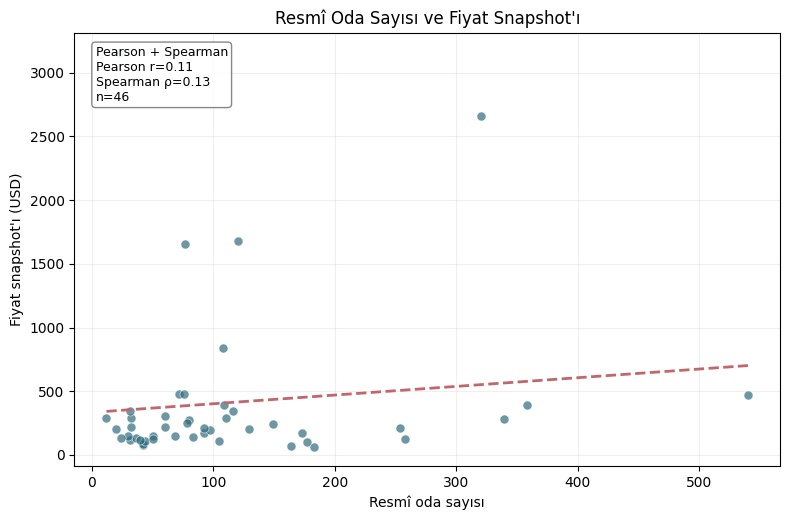

/var/folders/35/w7v4jvv930z1wthrlzsp49th0000gn/T/ipykernel_52183/3711770437.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=True)


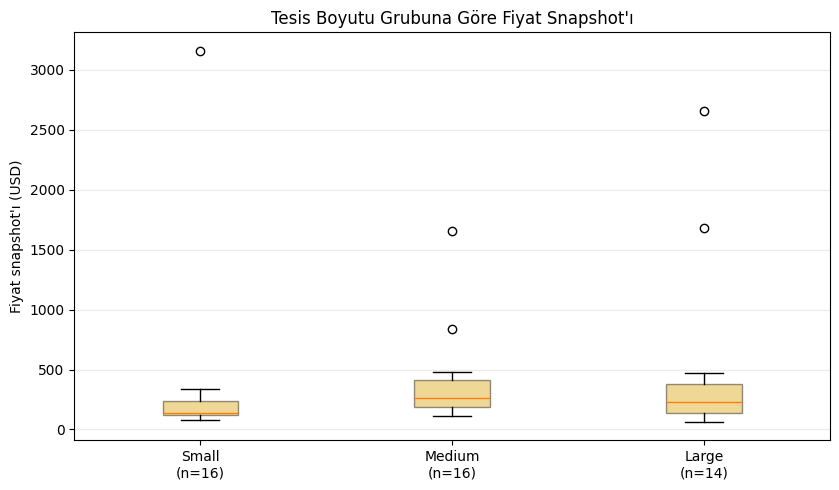

In [18]:
room_price_corr = correlation_table(correlation_results(
    official_df, "official_room_count", "search_price_usd_snapshot", "room_count vs price_snapshot"
))
display(room_price_corr)
scatter_with_note(
    official_df, "official_room_count", "search_price_usd_snapshot",
    "Resmî Oda Sayısı ve Fiyat Snapshot'ı", "Resmî oda sayısı", "Fiyat snapshot'ı (USD)",
    "room_count_vs_price.png",
)
grouped_boxplot(
    official_df, "hotel_size_group", "search_price_usd_snapshot", SIZE_LABELS,
    "Tesis Boyutu Grubuna Göre Fiyat Snapshot'ı", "Fiyat snapshot'ı (USD)", "price_by_size.png", color=HIGHLIGHT,
)


In [19]:
room_price_spearman = room_price_corr.loc[room_price_corr["method"].eq("spearman")].iloc[0]
display(Markdown(
    f"**Bulgu:** Oda sayısı ile fiyat snapshot'ı arasındaki Spearman ilişkisi "
    f"ρ={room_price_spearman.coefficient:.2f} (p={room_price_spearman.p_value:.3f}, "
    f"n={int(room_price_spearman.n)}). Bu ilişki tesis büyüklüğü ile gecelik oda fiyatı arasında "
    f"nedensel bir mekanizma kurmaz."
))


**Bulgu:** Oda sayısı ile fiyat snapshot'ı arasındaki Spearman ilişkisi ρ=0.13 (p=0.391, n=46). Bu ilişki tesis büyüklüğü ile gecelik oda fiyatı arasında nedensel bir mekanizma kurmaz.

### 10. Yatak kapasitesi ve oda başına yatak

Önce oda ve yatak sayısının aynı kapasite boyutunu ne ölçüde temsil ettiği kontrol edilir. İlişki
çok yüksekse rating/review/fiyat için dört benzer grafik tekrarlanmaz. `beds_per_room` yalnızca
pozitif oda ve yatak sayılarında hesaplanır; oda tipleri hakkında doğrudan bilgi vermez.


,official_bed_count
count,52.000
mean,267.269
std,246.252
min,36.000
25%,94.250
50%,179.500
75%,354.500
max,"1,080.000"


,analysis,method,n,coefficient,p_value
0,room_count vs bed_count,pearson,52,0.975,0.000
1,room_count vs bed_count,spearman,52,0.984,0.000


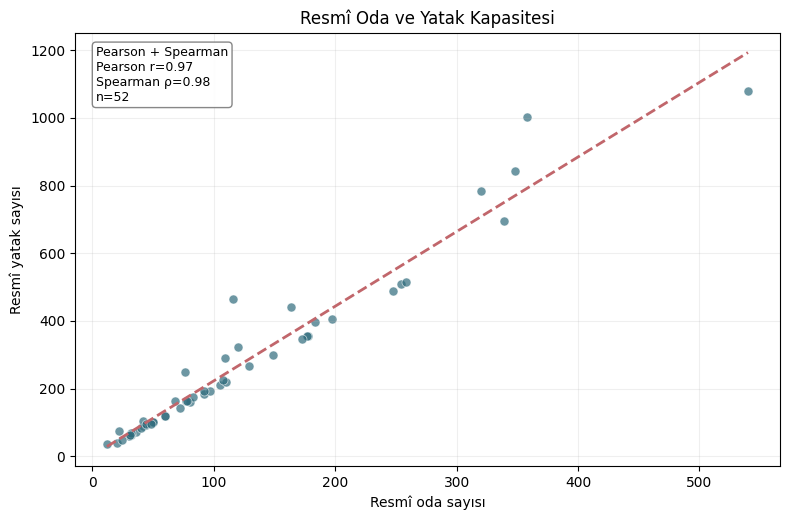

,beds_per_room
count,52.000
mean,2.228
std,0.422
min,1.968
25%,2.000
50%,2.027
75%,2.170
max,4.000


,count,median
official_star_rating_verified,,
2.000,3,2.143
3.000,10,2.000
4.000,17,2.000
5.000,21,2.078


,count,median
area,,
Türkbükü,1,3.455
Kadıkalesi,2,3.030
Torba,9,2.188
Bitez,6,2.093
Turgutreis,4,2.082
Yalıkavak,3,2.074
Gündoğan,6,2.043
Akyarlar,4,2.000
Bodrum Merkez,4,2.000


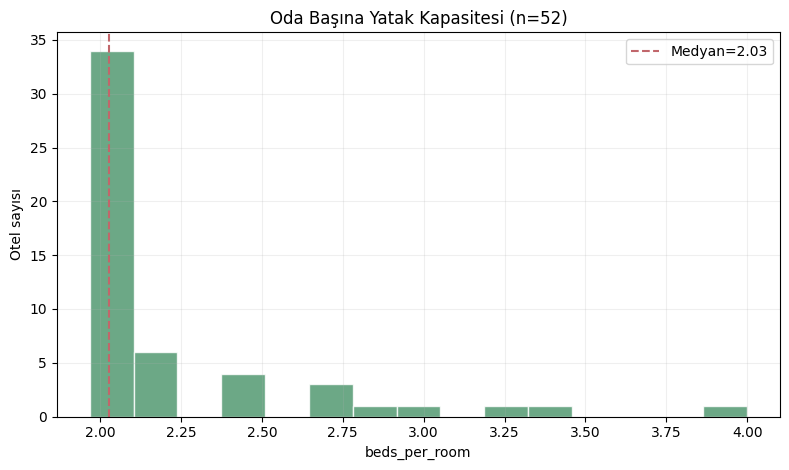

PosixPath('/Users/nihatkutukoglu/Downloads/bodrum-otel/reports/figures/hotel_attributes/beds_per_room_distribution.png')

In [20]:
room_bed_corr = correlation_table(correlation_results(
    official_df, "official_room_count", "official_bed_count", "room_count vs bed_count"
))
bed_desc = official_df["official_bed_count"].describe(percentiles=[0.25, 0.5, 0.75])
display(bed_desc.to_frame("official_bed_count"))
display(room_bed_corr)
scatter_with_note(
    official_df, "official_room_count", "official_bed_count",
    "Resmî Oda ve Yatak Kapasitesi", "Resmî oda sayısı", "Resmî yatak sayısı",
    "room_count_vs_bed_count.png",
)

valid_capacity = official_df["official_room_count"].gt(0) & official_df["official_bed_count"].gt(0)
official_df["beds_per_room"] = np.where(
    valid_capacity,
    official_df["official_bed_count"] / official_df["official_room_count"],
    np.nan,
)
bpr = official_df["beds_per_room"].replace([np.inf, -np.inf], np.nan).dropna()
display(bpr.describe(percentiles=[0.25, 0.5, 0.75]).to_frame("beds_per_room"))
display(official_df.groupby("official_star_rating_verified")["beds_per_room"].agg(["count", "median"]))
display(official_df.groupby("area")["beds_per_room"].agg(["count", "median"]).sort_values("median", ascending=False))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(bpr, bins="auto", color=SECONDARY, alpha=0.82, edgecolor="white")
ax.axvline(bpr.median(), color=ACCENT, linestyle="--", label=f"Medyan={bpr.median():.2f}")
ax.set(title=f"Oda Başına Yatak Kapasitesi (n={len(bpr)})", xlabel="beds_per_room", ylabel="Otel sayısı")
ax.legend(); ax.grid(alpha=0.2)
save_fig(fig, "beds_per_room_distribution.png")


In [21]:
room_bed_spearman = room_bed_corr.loc[room_bed_corr["method"].eq("spearman")].iloc[0]
redundancy_note = (
    "çok yüksek olduğu için yatak sayısı rating, yorum ve fiyat için oda sayısını tekrar eden ayrı grafiklerle çoğaltılmadı"
    if abs(room_bed_spearman.coefficient) >= 0.90 else
    "0.90 eşiğinin altında olduğu için yatak sayısı oda sayısından kısmen farklı bir kapasite ölçüsü olabilir"
)
display(Markdown(
    f"**Bulgu:** Oda–yatak Spearman ilişkisi ρ={room_bed_spearman.coefficient:.2f} "
    f"(n={int(room_bed_spearman.n)}); ilişki {redundancy_note}. Oda başına yatak medyanı "
    f"{bpr.median():.2f}'dir ve oda tipi dağılımını doğrudan göstermez."
))


**Bulgu:** Oda–yatak Spearman ilişkisi ρ=0.98 (n=52); ilişki çok yüksek olduğu için yatak sayısı rating, yorum ve fiyat için oda sayısını tekrar eden ayrı grafiklerle çoğaltılmadı. Oda başına yatak medyanı 2.03'dir ve oda tipi dağılımını doğrudan göstermez.

### 11. Resmî tesis tipi

**Soru:** Resmî tesis tipleri rating, yorum, fiyat ve kapasite açısından nasıl ayrışıyor? Grafik yalnızca
`n ≥ 3` grupları içerir. Butik otel ve tatil köyü karşılaştırmaları örneklem yeterliyse ayrıca gösterilir.


,official_type,n,median_google_rating,median_review_count,price_n,median_price,room_n,median_room_count,median_bed_count
3,5 YILDIZLI OTEL,15,4.500,"1,016.000",15,388.000,15,109.000,268.000
2,4 YILDIZLI OTEL,13,4.300,"1,351.000",11,169.000,13,105.000,210.000
1,3 YILDIZLI OTEL,9,4.300,424.000,8,123.000,9,42.000,92.000
6,BUTİK OTEL,6,4.500,491.500,6,289.500,6,32.000,67.000
0,2 YILDIZLI OTEL,3,4.500,221.000,2,105.500,3,42.000,90.000
4,5 YILDIZLI T.K.,3,4.200,"2,121.000",2,"1,450.500",3,197.000,406.000
5,B-TİPİ TATİL KÖYÜ,1,4.700,"4,889.000",0,NaN,1,348.000,844.000
7,MÜSTAKİL APART,1,4.500,"3,245.000",1,343.000,1,116.000,464.000
8,ÖZEL TESİS KNL,1,4.600,"1,102.000",1,151.000,1,50.000,100.000


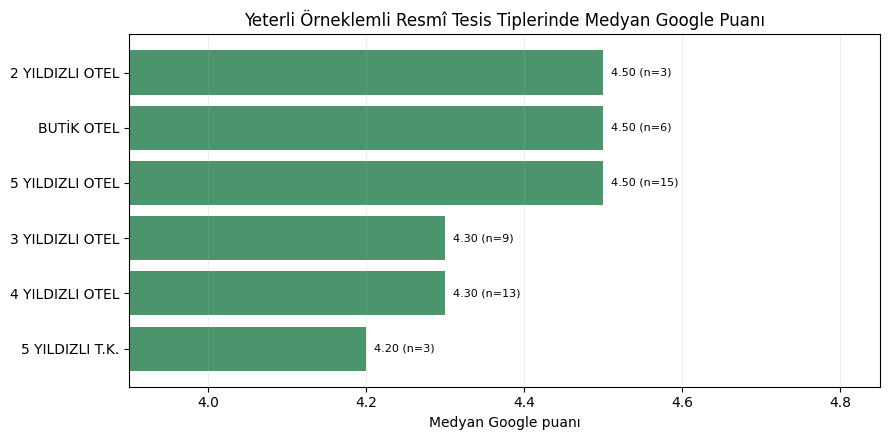

,group,n,median_rating,median_reviews,median_rooms,median_beds,price_n,median_price
0,BUTİK OTEL,6,4.500,491.500,32.000,67.000,6,289.500
1,TATİL KÖYÜ,11,4.500,"1,608.000",60.000,120.000,9,292.000
2,YILDIZLI OTEL,40,4.400,895.000,87.500,188.000,36,184.500


In [22]:
types = type_summary(official_df)
display(types)
eligible_types = types.loc[types["n"].ge(3)].copy()

fig, ax = plt.subplots(figsize=(9, max(4.5, len(eligible_types) * 0.55)))
ordered_types = eligible_types.sort_values("median_google_rating")
ax.barh(ordered_types["official_type"], ordered_types["median_google_rating"], color=SECONDARY)
for y, row in enumerate(ordered_types.itertuples()):
    ax.text(row.median_google_rating + 0.01, y, f"{row.median_google_rating:.2f} (n={row.n})", va="center", fontsize=8)
ax.set(title="Yeterli Örneklemli Resmî Tesis Tiplerinde Medyan Google Puanı", xlabel="Medyan Google puanı")
ax.set_xlim(max(0, ordered_types["median_google_rating"].min() - 0.3), min(5.1, ordered_types["median_google_rating"].max() + 0.35))
ax.grid(axis="x", alpha=0.2)
save_fig(fig, "official_type_median_rating.png")

boutique = official_df.loc[official_df["official_type"].eq("BUTİK OTEL")]
holiday_mask = official_df["official_type"].str.contains("TATİL KÖYÜ|T.K.", case=False, na=False)
holiday = official_df.loc[holiday_mask]
standard = official_df.loc[official_df["official_type"].str.contains("YILDIZLI OTEL", case=False, na=False)]
comparison_rows = []
for label, group in [("BUTİK OTEL", boutique), ("TATİL KÖYÜ", holiday), ("YILDIZLI OTEL", standard)]:
    if len(group):
        comparison_rows.append({
            "group": label, "n": len(group),
            "median_rating": group["google_rating"].median(),
            "median_reviews": group["google_review_count"].median(),
            "median_rooms": group["official_room_count"].median(),
            "median_beds": group["official_bed_count"].median(),
            "price_n": group["search_price_usd_snapshot"].count(),
            "median_price": group["search_price_usd_snapshot"].median(),
        })
type_comparison = pd.DataFrame(comparison_rows)
display(type_comparison)


In [23]:
small_type_warning = types.loc[types["n"].lt(3), ["official_type", "n"]]
display(Markdown(
    f"**Bulgu:** {len(types)} resmî tip gözleniyor; bunların {len(eligible_types)} tanesi n≥3 eşiğini "
    f"karşılıyor. Butik otel n={len(boutique)}, tatil köyü n={len(holiday)}; küçük grupların "
    f"medyanları genellenebilir profil olarak değil, yalnızca örneklem betimi olarak okunmalıdır."
))
display(small_type_warning)


**Bulgu:** 9 resmî tip gözleniyor; bunların 6 tanesi n≥3 eşiğini karşılıyor. Butik otel n=6, tatil köyü n=11; küçük grupların medyanları genellenebilir profil olarak değil, yalnızca örneklem betimi olarak okunmalıdır.

,official_type,n
5,B-TİPİ TATİL KÖYÜ,1
7,MÜSTAKİL APART,1
8,ÖZEL TESİS KNL,1


### 12. Destinasyon bazında resmî kapasite ve üst segment yoğunluğu

**Soru:** Yüksek güvenle eşleşen resmî oda/yatak kapasitesi ve doğrulanmış 5 yıldızlı arz hangi
destinasyonlarda yoğunlaşıyor? Adet ile `verified` tesisler içindeki pay ayrı gösterilir.


,area,matched_hotel_count,room_count_available,total_official_rooms,bed_count_available,total_official_beds,median_room_count,median_bed_count,verified_star_count,verified_5star_count,verified_4star_count,avg_google_rating,median_google_rating,avg_weighted_rating,price_n,median_price,verified_5star_share_pct
0,Torba,9,9,"1,303.000",9,"3,040.000",76.000,164.000,9,5,2,4.478,4.400,4.454,7,284.000,55.600
1,Gümbet,7,7,"1,296.000",7,"2,732.000",149.000,298.000,7,2,3,4.143,4.200,4.234,7,111.000,28.600
2,Turgutreis,4,4,859.000,4,"2,034.000",220.500,456.000,4,4,0,4.300,4.300,4.316,4,214.500,100.000
3,Bitez,6,6,626.000,6,"1,309.000",87.500,179.500,6,3,2,4.200,4.150,4.249,6,158.000,50.000
4,Bodrum Merkez,4,4,392.000,4,784.000,84.500,169.000,4,2,1,4.575,4.650,4.515,4,183.500,50.000
5,Akyarlar,4,4,349.000,4,698.000,70.000,140.000,4,0,3,4.550,4.450,4.509,3,216.000,0.000
6,Gündoğan,6,6,348.000,6,712.000,42.000,88.000,6,1,3,4.500,4.450,4.423,6,177.500,16.700
7,Ortakent-Yahşi,3,3,316.000,3,631.000,44.000,95.000,3,0,1,4.233,4.500,4.208,1,130.000,0.000
8,Kadıkalesi,2,2,313.000,2,870.000,156.500,435.000,2,1,1,4.250,4.250,4.274,1,343.000,50.000
9,Yalıkavak,3,3,248.000,3,576.000,108.000,224.000,2,2,0,4.400,4.400,4.381,3,388.000,100.000


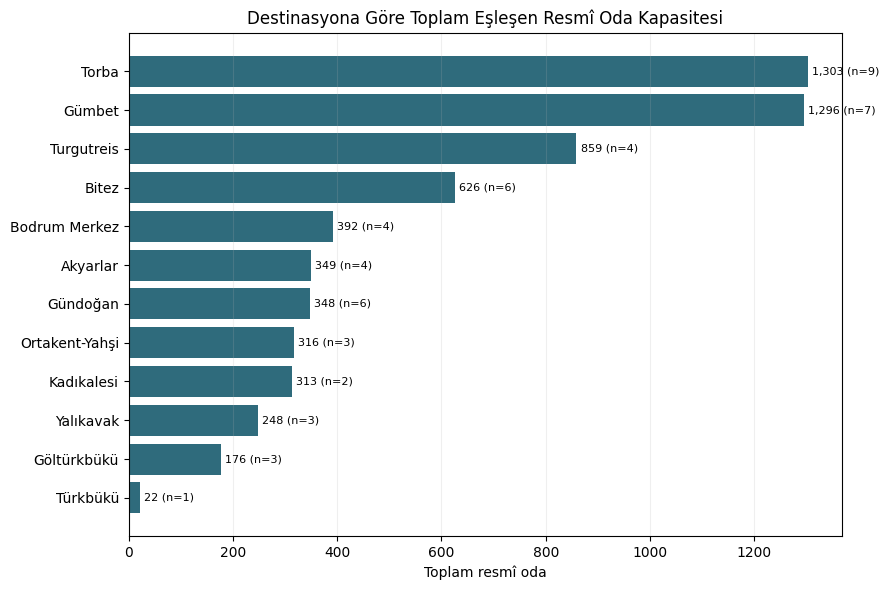

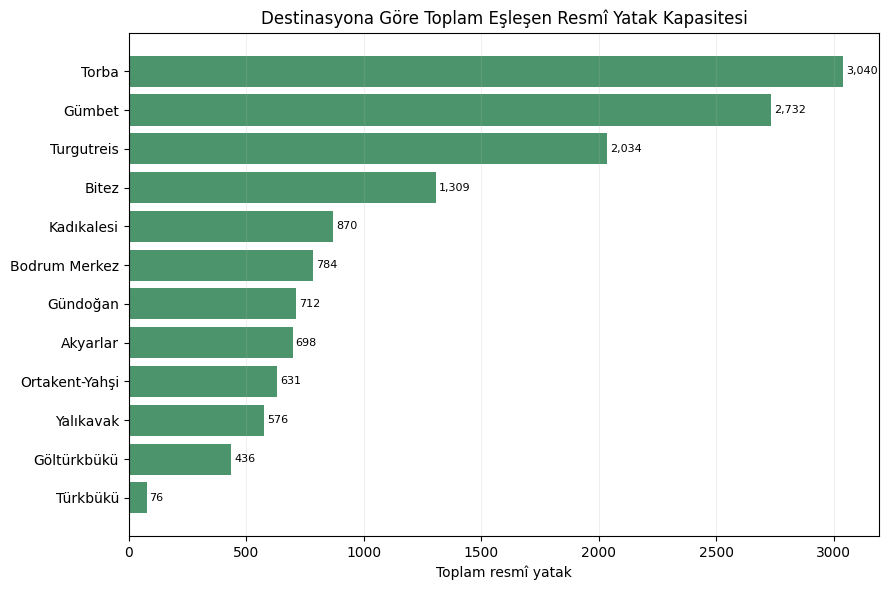

PosixPath('/Users/nihatkutukoglu/Downloads/bodrum-otel/reports/figures/hotel_attributes/destination_bed_capacity.png')

In [24]:
destinations = destination_capacity(official_df)
display(destinations)

room_order = destinations.sort_values("total_official_rooms")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(room_order["area"], room_order["total_official_rooms"], color=PRIMARY)
for y, row in enumerate(room_order.itertuples()):
    ax.text(row.total_official_rooms + 8, y, f"{row.total_official_rooms:,.0f} (n={row.room_count_available})", va="center", fontsize=8)
ax.set(title="Destinasyona Göre Toplam Eşleşen Resmî Oda Kapasitesi", xlabel="Toplam resmî oda")
ax.grid(axis="x", alpha=0.2)
save_fig(fig, "destination_room_capacity.png")

bed_order = destinations.sort_values("total_official_beds")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(bed_order["area"], bed_order["total_official_beds"], color=SECONDARY)
for y, row in enumerate(bed_order.itertuples()):
    ax.text(row.total_official_beds + 12, y, f"{row.total_official_beds:,.0f}", va="center", fontsize=8)
ax.set(title="Destinasyona Göre Toplam Eşleşen Resmî Yatak Kapasitesi", xlabel="Toplam resmî yatak")
ax.grid(axis="x", alpha=0.2)
save_fig(fig, "destination_bed_capacity.png")


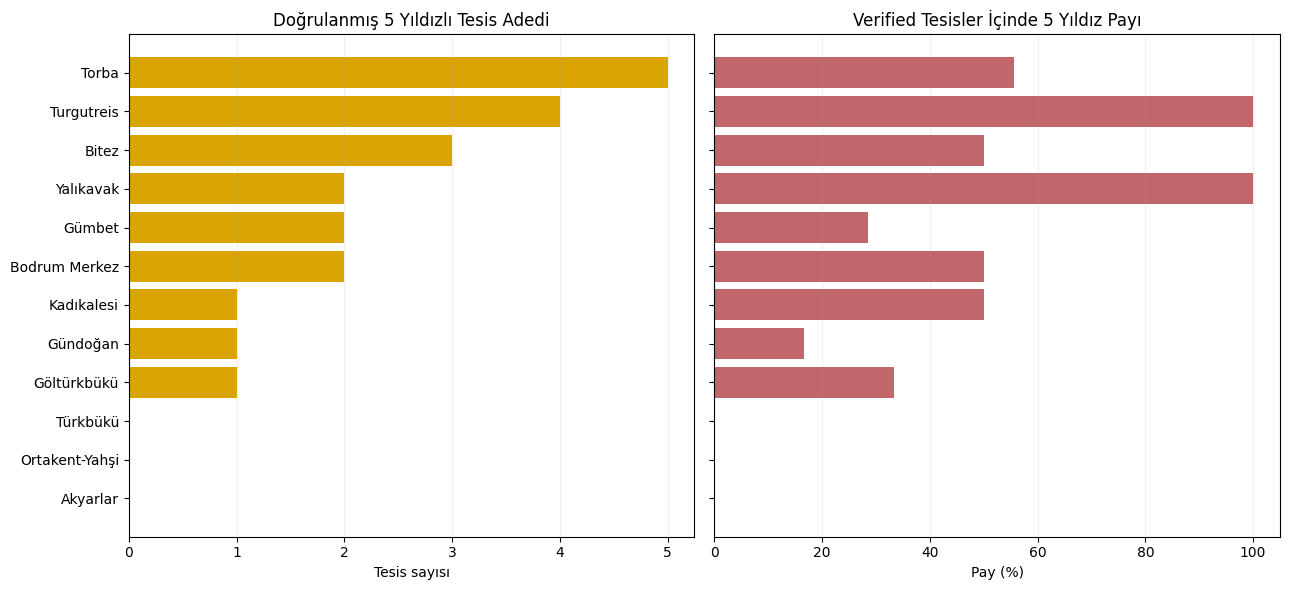

PosixPath('/Users/nihatkutukoglu/Downloads/bodrum-otel/reports/figures/hotel_attributes/five_star_count_and_share_by_destination.png')

In [25]:
plot_dest = destinations.sort_values(["verified_5star_count", "area"])
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
axes[0].barh(plot_dest["area"], plot_dest["verified_5star_count"], color=HIGHLIGHT)
axes[0].set(title="Doğrulanmış 5 Yıldızlı Tesis Adedi", xlabel="Tesis sayısı")
axes[1].barh(plot_dest["area"], plot_dest["verified_5star_share_pct"], color=ACCENT)
axes[1].set(title="Verified Tesisler İçinde 5 Yıldız Payı", xlabel="Pay (%)")
for ax in axes: ax.grid(axis="x", alpha=0.2)
save_fig(fig, "five_star_count_and_share_by_destination.png")


In [26]:
top_capacity = destinations.sort_values("total_official_rooms", ascending=False).iloc[0]
top_share = destinations.loc[destinations["verified_star_count"].gt(0)].sort_values(
    ["verified_5star_share_pct", "verified_5star_count"], ascending=False
).iloc[0]
display(Markdown(
    f"**Bulgu:** Eşleşen resmî oda kapasitesi en yüksek destinasyon {top_capacity.area} "
    f"({top_capacity.total_official_rooms:,.0f} oda, n={top_capacity.room_count_available} tesis). "
    f"Verified tesisler içindeki en yüksek 5 yıldız payı {top_share.area} için "
    f"%{top_share.verified_5star_share_pct:.1f} (adet={top_share.verified_5star_count}, "
    f"verified n={top_share.verified_star_count}). Bu toplamlar yalnızca yüksek güvenli eşleşmeleri kapsar."
))


**Bulgu:** Eşleşen resmî oda kapasitesi en yüksek destinasyon Torba (1,303 oda, n=9 tesis). Verified tesisler içindeki en yüksek 5 yıldız payı Turgutreis için %100.0 (adet=4, verified n=4). Bu toplamlar yalnızca yüksek güvenli eşleşmeleri kapsar.

### 13. Destinasyon kapasitesi ↔ rating ve fiyat

Yalnızca gözlenen destinasyonlar kullanılır; destinasyon sayısı küçük olduğu için korelasyonlar
keşifsel ve ihtiyatlı yorumlanır. Noktalar alan adlarıyla etiketlenir.


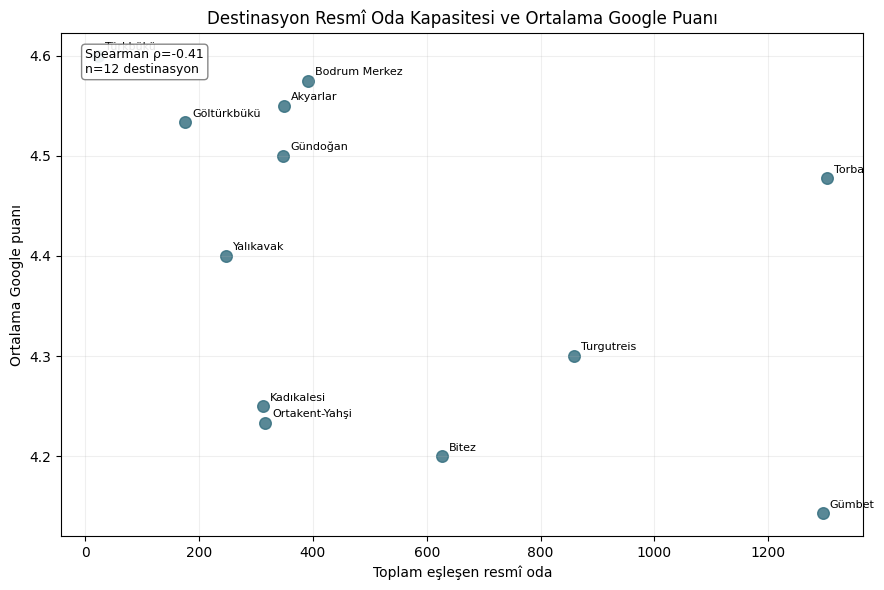

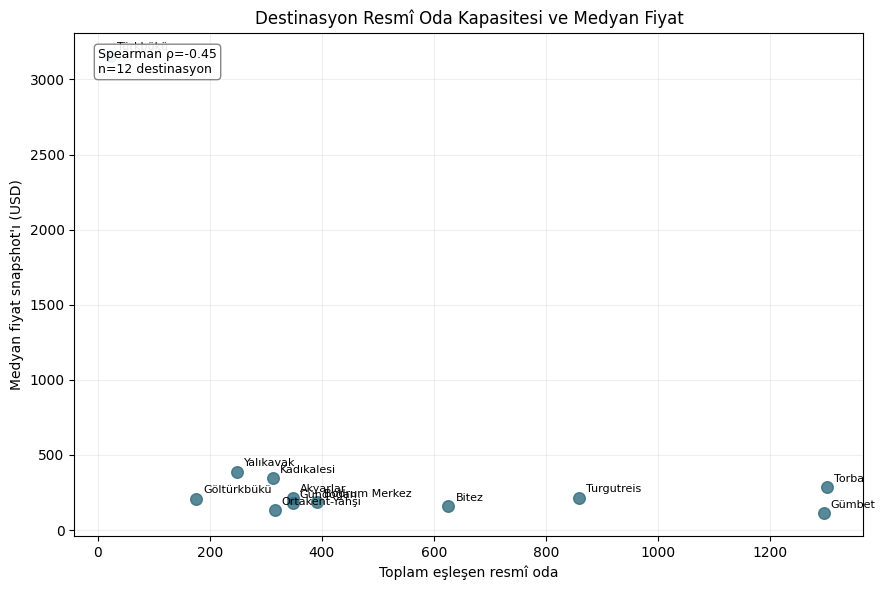

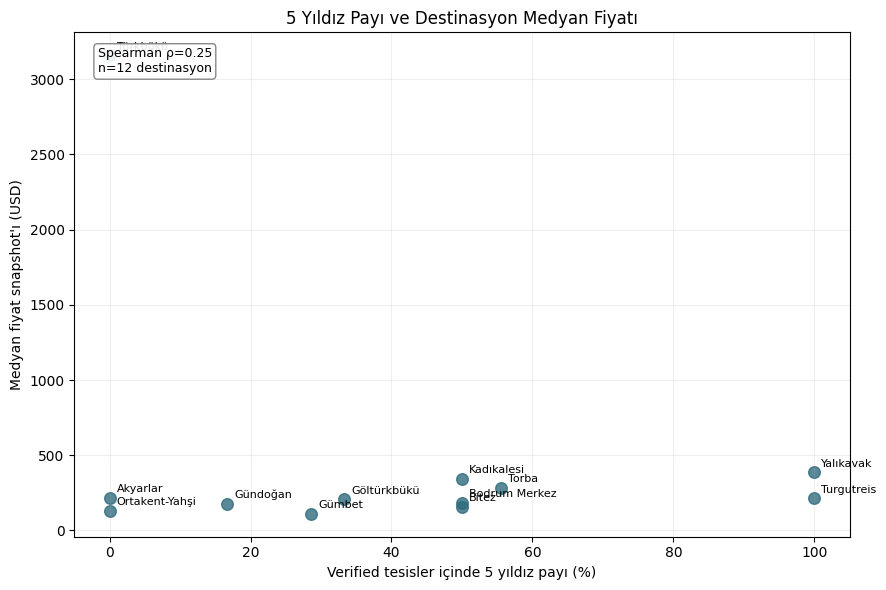

In [27]:
annotated_area_scatter(
    destinations, "total_official_rooms", "avg_google_rating",
    "Destinasyon Resmî Oda Kapasitesi ve Ortalama Google Puanı",
    "Toplam eşleşen resmî oda", "Ortalama Google puanı", "destination_capacity_vs_rating.png",
)
annotated_area_scatter(
    destinations, "total_official_rooms", "median_price",
    "Destinasyon Resmî Oda Kapasitesi ve Medyan Fiyat",
    "Toplam eşleşen resmî oda", "Medyan fiyat snapshot'ı (USD)", "destination_capacity_vs_price.png",
)
annotated_area_scatter(
    destinations, "verified_5star_share_pct", "median_price",
    "5 Yıldız Payı ve Destinasyon Medyan Fiyatı",
    "Verified tesisler içinde 5 yıldız payı (%)", "Medyan fiyat snapshot'ı (USD)", "five_star_share_vs_price.png",
)


In [28]:
area_room_rating_rho = destinations["total_official_rooms"].corr(destinations["avg_google_rating"], method="spearman")
area_room_price_pair = destinations.dropna(subset=["total_official_rooms", "median_price"])
area_room_price_rho = area_room_price_pair["total_official_rooms"].corr(area_room_price_pair["median_price"], method="spearman")
area_share_price_pair = destinations.dropna(subset=["verified_5star_share_pct", "median_price"])
area_share_price_rho = area_share_price_pair["verified_5star_share_pct"].corr(area_share_price_pair["median_price"], method="spearman")
display(Markdown(
    f"**Bulgu:** Destinasyon düzeyinde oda kapasitesi–ortalama rating Spearman ρ={area_room_rating_rho:.2f} "
    f"(n={len(destinations)}); oda kapasitesi–medyan fiyat ρ={area_room_price_rho:.2f} "
    f"(n={len(area_room_price_pair)}); 5 yıldız payı–medyan fiyat ρ={area_share_price_rho:.2f} "
    f"(n={len(area_share_price_pair)}). Küçük destinasyon örneklemi genelleme gücünü sınırlar."
))


**Bulgu:** Destinasyon düzeyinde oda kapasitesi–ortalama rating Spearman ρ=-0.41 (n=12); oda kapasitesi–medyan fiyat ρ=-0.45 (n=12); 5 yıldız payı–medyan fiyat ρ=0.25 (n=12). Küçük destinasyon örneklemi genelleme gücünü sınırlar.

### 14. Yıldız × destinasyon dağılımı

Adet tabanlı çapraz tablo, yüksek sınıf tesis arzının mekânsal dağılımını gösterir. Boş kombinasyonlar
gerçek sıfır gözlem olarak `0` ile gösterilir.


official_star_rating_verified,1.000,2.000,3.000,4.000,5.000
area,,,,,
Akyarlar,0,0,1,3,0
Bitez,0,0,1,2,3
Bodrum Merkez,0,0,1,1,2
Göltürkbükü,0,1,1,0,1
Gümbet,0,1,1,3,2
Gündoğan,0,0,2,3,1
Kadıkalesi,0,0,0,1,1
Ortakent-Yahşi,0,1,1,1,0
Torba,0,0,2,2,5


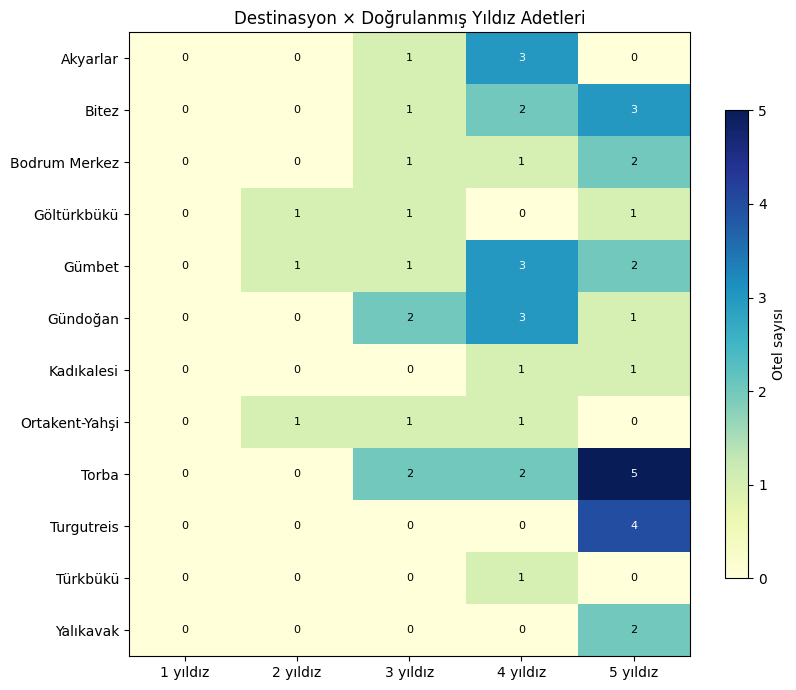

PosixPath('/Users/nihatkutukoglu/Downloads/bodrum-otel/reports/figures/hotel_attributes/star_area_heatmap.png')

In [29]:
star_area = pd.crosstab(
    official_df["area"], official_df["official_star_rating_verified"]
).reindex(columns=[1.0, 2.0, 3.0, 4.0, 5.0], fill_value=0)
display(star_area)
fig, ax = plt.subplots(figsize=(8.5, 7))
matrix = star_area.to_numpy()
image = ax.imshow(matrix, cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(len(star_area.columns)), [f"{int(c)} yıldız" for c in star_area.columns])
ax.set_yticks(range(len(star_area.index)), star_area.index)
ax.set_title("Destinasyon × Doğrulanmış Yıldız Adetleri")
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, str(matrix[i, j]), ha="center", va="center", fontsize=8,
                color="white" if matrix[i, j] > matrix.max() / 2 else "black")
fig.colorbar(image, ax=ax, shrink=0.75, label="Otel sayısı")
save_fig(fig, "star_area_heatmap.png")


### 15. Destinasyon içi konum ve yorum güveni

`rating_gap_from_area_median`, `price_ratio_to_area_median`, `weighted_google_rating` ve
`review_confidence_weight` önceki feature engineering aşamasından gelir. Böylece yıldız grupları
kendi destinasyon bağlamı içinde ve yorum hacmi dikkate alınarak özetlenebilir.


,star,n,median_raw_rating,median_weighted_rating,median_review_confidence,median_rating_gap_from_area,price_ratio_n,median_price_ratio_to_area,median_price_percentile_in_area
0,2.000,3,4.500,4.393,0.322,0.200,2,0.709,0.233
1,3.000,10,4.300,4.339,0.488,-0.000,9,0.765,0.357
2,4.000,17,4.400,4.380,0.742,0.000,15,1.080,0.667
3,5.000,21,4.600,4.460,0.772,0.150,19,1.883,0.833


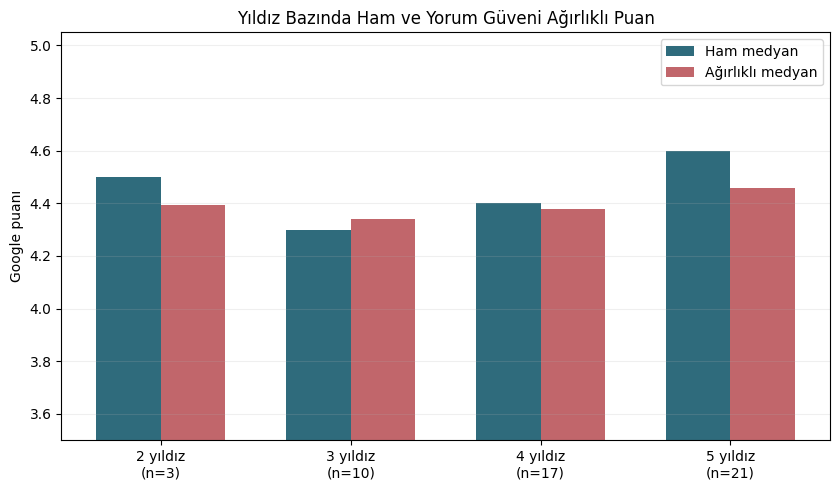

PosixPath('/Users/nihatkutukoglu/Downloads/bodrum-otel/reports/figures/hotel_attributes/raw_vs_weighted_rating_by_star.png')

In [30]:
context_by_star = (
    official_df.dropna(subset=["official_star_rating_verified"])
    .groupby("official_star_rating_verified")
    .agg(
        n=("hotel_id", "size"),
        median_raw_rating=("google_rating", "median"),
        median_weighted_rating=("weighted_google_rating", "median"),
        median_review_confidence=("review_confidence_weight", "median"),
        median_rating_gap_from_area=("rating_gap_from_area_median", "median"),
        price_ratio_n=("price_ratio_to_area_median", "count"),
        median_price_ratio_to_area=("price_ratio_to_area_median", "median"),
        median_price_percentile_in_area=("price_percentile_within_area", "median"),
    ).reset_index().rename(columns={"official_star_rating_verified": "star"})
)
display(context_by_star)

fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.arange(len(context_by_star))
width = 0.34
ax.bar(x - width/2, context_by_star["median_raw_rating"], width, label="Ham medyan", color=PRIMARY)
ax.bar(x + width/2, context_by_star["median_weighted_rating"], width, label="Ağırlıklı medyan", color=ACCENT)
ax.set_xticks(x, [f"{int(s)} yıldız\n(n={n})" for s, n in zip(context_by_star["star"], context_by_star["n"])])
ax.set_ylim(min(3.5, context_by_star[["median_raw_rating", "median_weighted_rating"]].min().min() - 0.2), 5.05)
ax.set(title="Yıldız Bazında Ham ve Yorum Güveni Ağırlıklı Puan", ylabel="Google puanı")
ax.legend(); ax.grid(axis="y", alpha=0.2)
save_fig(fig, "raw_vs_weighted_rating_by_star.png")


In [31]:
display(Markdown(
    "**Bulgu:** Alan medyanından rating farkı ve alan medyanına fiyat oranı, yıldız gruplarını "
    "destinasyonun genel fiyat/puan düzeyinden kısmen ayırır. Ağırlıklı puan düşük yorumlu uç ham "
    "puanları örneklem ortalamasına yaklaştırır; gerçek müşteri puanının yerine geçen yeni bir ölçüm değildir."
))


**Bulgu:** Alan medyanından rating farkı ve alan medyanına fiyat oranı, yıldız gruplarını destinasyonun genel fiyat/puan düzeyinden kısmen ayırır. Ağırlıklı puan düşük yorumlu uç ham puanları örneklem ortalamasına yaklaştırır; gerçek müşteri puanının yerine geçen yeni bir ölçüm değildir.

### 16. Açıklanabilir iki boyutlu görseller

İlk grafik yıldız–ağırlıklı rating ilişkisini yorum hacmiyle birlikte gösterir. İkinci grafik oda
kapasitesi ve ağırlıklı memnuniyeti örneklem medyanlarıyla dört gruba ayırır; bu bir ML/anomali
modeli değildir.


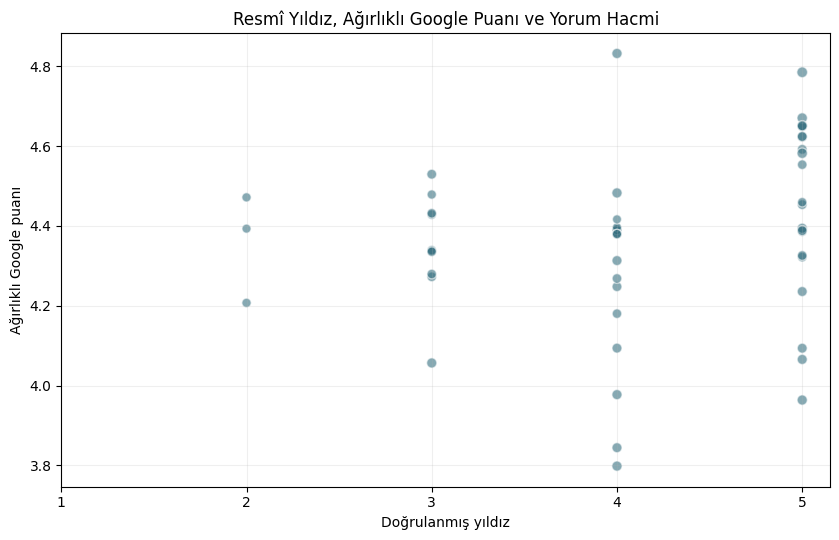

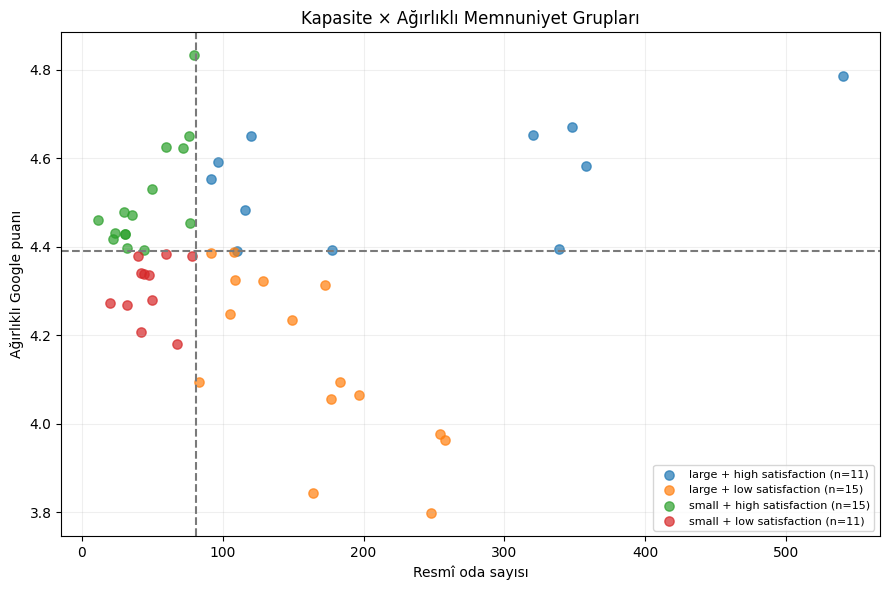

,capacity_satisfaction_group,hotel_name,area,official_room_count,weighted_google_rating,google_review_count,official_star_rating_verified
67,large + high satisfaction,Selectum Colours Bodrum,Gümbet,540.000,4.785,13412,5.000
147,large + high satisfaction,Rixos Premium Bodrum,Torba,348.000,4.671,4889,5.000
155,large + high satisfaction,Voyage Torba,Torba,320.000,4.651,2753,5.000
55,large + high satisfaction,"Mandarin Oriental, Bodrum",Göltürkbükü,120.000,4.651,2728,5.000
46,large + high satisfaction,The Marmara Bodrum,Bodrum Merkez,97.000,4.592,987,5.000
159,large + high satisfaction,La Blanche Resort Bodrum,Turgutreis,358.000,4.582,5754,5.000
94,large + high satisfaction,Mivara Luxury Bodrum,Gündoğan,92.000,4.554,606,5.000
113,large + high satisfaction,Sianji Well-Being Resort Thermal & Spa,Kadıkalesi,116.000,4.483,3245,4.000
149,large + high satisfaction,Samara Hotel,Torba,339.000,4.394,2488,5.000
12,large + high satisfaction,"Sentido Bellazure - Akyarlar, Bodrum / Turkey",Akyarlar,178.000,4.392,1650,4.000


In [32]:
bubble = official_df.dropna(subset=["official_star_rating_verified", "weighted_google_rating", "google_review_count"])
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sizes = 25 + 35 * np.log1p(bubble["google_review_count"]) / np.log1p(bubble["google_review_count"]).max()
ax.scatter(bubble["official_star_rating_verified"], bubble["weighted_google_rating"], s=sizes,
           color=PRIMARY, alpha=0.58, edgecolor="white")
ax.set_xticks([1, 2, 3, 4, 5])
ax.set(title="Resmî Yıldız, Ağırlıklı Google Puanı ve Yorum Hacmi", xlabel="Doğrulanmış yıldız", ylabel="Ağırlıklı Google puanı")
ax.grid(alpha=0.2)
save_fig(fig, "star_weighted_rating_bubble.png")

quadrant = official_df.dropna(subset=["official_room_count", "weighted_google_rating"]).copy()
room_median = quadrant["official_room_count"].median()
rating_median = quadrant["weighted_google_rating"].median()
quadrant["capacity_satisfaction_group"] = np.select(
    [
        quadrant["official_room_count"].ge(room_median) & quadrant["weighted_google_rating"].ge(rating_median),
        quadrant["official_room_count"].ge(room_median) & quadrant["weighted_google_rating"].lt(rating_median),
        quadrant["official_room_count"].lt(room_median) & quadrant["weighted_google_rating"].ge(rating_median),
    ],
    ["large + high satisfaction", "large + low satisfaction", "small + high satisfaction"],
    default="small + low satisfaction",
)
fig, ax = plt.subplots(figsize=(9, 6))
for label, group in quadrant.groupby("capacity_satisfaction_group"):
    ax.scatter(group["official_room_count"], group["weighted_google_rating"], s=45, alpha=0.7, label=f"{label} (n={len(group)})")
ax.axvline(room_median, color=NEUTRAL, linestyle="--")
ax.axhline(rating_median, color=NEUTRAL, linestyle="--")
ax.set(title="Kapasite × Ağırlıklı Memnuniyet Grupları", xlabel="Resmî oda sayısı", ylabel="Ağırlıklı Google puanı")
ax.legend(fontsize=8); ax.grid(alpha=0.2)
save_fig(fig, "capacity_satisfaction_quadrant.png")

quadrant_output = quadrant[[
    "capacity_satisfaction_group", "hotel_name", "area", "official_room_count",
    "weighted_google_rating", "google_review_count", "official_star_rating_verified",
]].sort_values(["capacity_satisfaction_group", "weighted_google_rating"], ascending=[True, False])
display(quadrant_output)


### 17. Kontrollü istatistiksel test

Yıldız gruplarında dağılım ve örneklem büyüklükleri eşit olmadığı için parametrik ANOVA yerine
Kruskal–Wallis kullanılır. Yalnız p-değeri değil, grup medyanları ve epsilon-kare etki büyüklüğü de
raporlanır. Anlamlı değilse “fark yoktur” denmez.


In [33]:
kruskal_result = kruskal_star_rating_test(official_df)
correlation_reports = pd.concat([
    star_rating_corr, room_rating_corr, room_review_corr, room_price_corr, room_bed_corr
], ignore_index=True)
statistical_tests = pd.concat([
    kruskal_result,
    correlation_reports.rename(columns={"analysis": "test", "coefficient": "statistic"}).assign(
        group_count=np.nan, group_sizes=pd.NA, effect_size_epsilon_squared=np.nan, status="COMPUTED"
    )[["test", "n", "group_count", "group_sizes", "statistic", "p_value", "effect_size_epsilon_squared", "status", "method"]],
], ignore_index=True, sort=False)
display(kruskal_result)
display(statistical_tests)


,test,n,group_count,group_sizes,statistic,p_value,effect_size_epsilon_squared,status
0,Kruskal-Wallis: star vs google_rating,51,4,"[3, 10, 17, 21]",5.529,0.137,0.054,COMPUTED


,test,n,group_count,group_sizes,statistic,p_value,effect_size_epsilon_squared,status,method
0,Kruskal-Wallis: star vs google_rating,51,4.000,"[3, 10, 17, 21]",5.529,0.137,0.054,COMPUTED,NaN
1,official_star_rating_verified vs google_rating,51,NaN,NaN,0.238,0.092,NaN,COMPUTED,spearman
2,room_count vs google_rating,52,NaN,NaN,-0.056,0.693,NaN,COMPUTED,pearson
3,room_count vs google_rating,52,NaN,NaN,-0.165,0.242,NaN,COMPUTED,spearman
4,room_count vs google_review_count,52,NaN,NaN,0.859,0.000,NaN,COMPUTED,spearman
5,room_count vs price_snapshot,46,NaN,NaN,0.115,0.447,NaN,COMPUTED,pearson
6,room_count vs price_snapshot,46,NaN,NaN,0.129,0.391,NaN,COMPUTED,spearman
7,room_count vs bed_count,52,NaN,NaN,0.975,0.000,NaN,COMPUTED,pearson
8,room_count vs bed_count,52,NaN,NaN,0.984,0.000,NaN,COMPUTED,spearman


In [34]:
kw = kruskal_result.iloc[0]
kw_interpretation = "gruplar arasında dağılım farkı için kanıt görülüyor" if kw.p_value < 0.05 else "bu örneklemde dağılım farkı için güçlü kanıt görülmüyor"
display(Markdown(
    f"**Bulgu:** Kruskal–Wallis H={kw.statistic:.2f}, p={kw.p_value:.3f}, "
    f"epsilon-kare={kw.effect_size_epsilon_squared:.3f}, n={int(kw.n)}; {kw_interpretation}. "
    f"Küçük yıldız grupları test gücünü sınırlar ve anlamsız sonuç eşitlik kanıtı değildir."
))


**Bulgu:** Kruskal–Wallis H=5.53, p=0.137, epsilon-kare=0.054, n=51; bu örneklemde dağılım farkı için güçlü kanıt görülmüyor. Küçük yıldız grupları test gücünü sınırlar ve anlamsız sonuç eşitlik kanıtı değildir.

### 18. İstatistiksel olarak ilginç vaka tablosu

Kurallar önceden tanımlı ve açıklanabilirdir: 5 yıldız + görece düşük ağırlıklı puan, 3 yıldız ve
altı + yüksek ağırlıklı puan, yüksek kapasite + düşük puan, küçük kapasite + yüksek yorum, alanına
göre yüksek fiyat oranı + düşük puan ve tersi. Bunlar inceleme adaylarıdır, kalite hükmü değildir.


In [35]:
cases = interesting_cases(official_df)
display(cases)


,case_type,hotel_id,hotel_name,area,official_star_rating_verified,official_room_count,google_rating,weighted_google_rating,google_review_count,search_price_usd_snapshot,price_ratio_to_area_median
0,5_star_relatively_low_weighted_rating,BOD161,MyElla Hotel Resort & Spa,Turgutreis,5.000,258.000,3.900,3.964,2926,125.000,1.012
1,5_star_relatively_low_weighted_rating,BOD113,Kadıkale Resort,Kadıkalesi,5.000,197.000,4.000,4.065,2121,NaN,NaN
2,5_star_relatively_low_weighted_rating,BOD163,Sundance Resort,Turgutreis,5.000,183.000,4.000,4.094,1344,66.000,0.534
3,5_star_relatively_low_weighted_rating,BOD072,VERY CHIC BODRUM,Gümbet,5.000,149.000,4.200,4.236,1670,241.000,1.883
4,5_star_relatively_low_weighted_rating,BOD033,Ramada Resort by Wyndham Bodrum,Bitez,5.000,129.000,4.300,4.322,870,206.000,1.567
5,up_to_3_star_high_weighted_rating,BOD036,Bodrium Hotel & SPA,Bodrum Merkez,3.000,50.000,4.600,4.530,1102,151.000,0.893
6,up_to_3_star_high_weighted_rating,BOD100,Villa Rustica Hotel,Gündoğan,3.000,30.000,4.700,4.479,243,145.000,0.765
7,up_to_3_star_high_weighted_rating,BOD048,Babana Hotel,Göltürkbükü,2.000,36.000,4.700,4.472,221,132.000,0.800
8,up_to_3_star_high_weighted_rating,BOD136,Zest Exclusive Hotel and Spa,Ortakent-Yahşi,3.000,24.000,4.500,4.432,467,130.000,1.000
9,up_to_3_star_high_weighted_rating,BOD008,LA BREZZA SUITE &HOTEL,Akyarlar,3.000,31.000,4.500,4.429,424,121.000,0.629


### 19. Raporların kaydedilmesi ve temel bulgular

In [36]:
output_paths = {
    "star_summary": REPORTS_DIR / "hotel_attributes_star_summary.csv",
    "size_summary": REPORTS_DIR / "hotel_attributes_size_summary.csv",
    "destination_capacity": REPORTS_DIR / "hotel_attributes_destination_capacity.csv",
    "type_summary": REPORTS_DIR / "hotel_attributes_type_summary.csv",
    "interesting_cases": REPORTS_DIR / "hotel_attributes_interesting_cases.csv",
    "statistical_tests": REPORTS_DIR / "hotel_attributes_statistical_tests.csv",
}

stars.to_csv(output_paths["star_summary"], index=False, encoding="utf-8-sig")
size_table.to_csv(output_paths["size_summary"], index=False, encoding="utf-8-sig")
destinations.to_csv(output_paths["destination_capacity"], index=False, encoding="utf-8-sig")
types.to_csv(output_paths["type_summary"], index=False, encoding="utf-8-sig")
cases.to_csv(output_paths["interesting_cases"], index=False, encoding="utf-8-sig")
statistical_tests.to_csv(output_paths["statistical_tests"], index=False, encoding="utf-8-sig")

def fmt(value, digits=2):
    return "hesaplanamadı" if pd.isna(value) else f"{value:.{digits}f}"

findings = []
findings.append(
    f"Ana 192 otelin {len(official_df)} tanesi (%{100 * len(official_df) / len(df):.1f}) yüksek güvenli resmî eşleşme ile analiz edildi."
)
findings.append(
    f"Doğrulanmış yıldız {int(df['official_star_rating_verified'].notna().sum())} otelde; oda ve yatak sayısı {int(df['official_room_count'].notna().sum())}/{int(df['official_bed_count'].notna().sum())} otelde mevcuttur."
)
findings.append(
    f"En geniş doğrulanmış yıldız grubu {int(largest_star['star'])} yıldızdır (n={int(largest_star['hotel_count'])}, pay %{largest_star['share_pct']:.1f})."
)
findings.append(
    f"Yıldız ile Google puanı arasındaki Spearman ilişki ρ={fmt(star_rho)} (p={fmt(star_p, 3)}, n={int(star_rating_corr.loc[0, 'n'])})."
)
if not premiums.empty:
    first_premium = premiums.iloc[0]
    findings.append(
        f"{int(first_premium['higher_star'])} yıldızlıların medyan fiyatı {int(first_premium['lower_star'])} yıldızlılara göre %{first_premium['median_price_premium_pct']:.1f} farklıdır (fiyat n={int(first_premium['higher_price_n'])}/{int(first_premium['lower_price_n'])})."
    )
findings.append(
    f"Resmî oda sayısı medyanı {rooms.median():.0f}; IQR {rooms.quantile(.25):.0f}–{rooms.quantile(.75):.0f} odadır."
)
findings.append(
    f"Oda sayısı ile Google puanı Spearman ρ={fmt(room_rating_spearman.coefficient)} (n={int(room_rating_spearman.n)})."
)
findings.append(
    f"Oda sayısı ile Google yorum hacmi Spearman ρ={fmt(room_review_spearman.coefficient)} (n={int(room_review_spearman.n)})."
)
findings.append(
    f"Oda sayısı ile fiyat snapshot'ı Spearman ρ={fmt(room_price_spearman.coefficient)} (n={int(room_price_spearman.n)})."
)
findings.append(
    f"Oda ve yatak kapasitesi Spearman ρ={fmt(room_bed_spearman.coefficient)} (n={int(room_bed_spearman.n)}); yatak sayısı büyük ölçüde aynı kapasite boyutunu temsil eder."
)
findings.append(
    f"Oda başına yatak kapasitesi medyanı {bpr.median():.2f}'dir; bu metrik oda tipi bilgisini doğrudan vermez."
)
findings.append(
    f"En yüksek toplam eşleşen resmî oda kapasitesi {top_capacity.area} bölgesindedir ({top_capacity.total_official_rooms:,.0f} oda; n={int(top_capacity.room_count_available)})."
)
findings.append(
    f"En yüksek verified 5 yıldız payı {top_share.area} bölgesindedir (%{top_share.verified_5star_share_pct:.1f}; adet={int(top_share.verified_5star_count)}, verified n={int(top_share.verified_star_count)})."
)
findings.append(
    f"Destinasyon düzeyinde toplam resmî oda kapasitesi ile ortalama rating Spearman ρ={fmt(area_room_rating_rho)} (n={len(destinations)})."
)
findings.append(
    f"Yıldız grupları için Kruskal–Wallis p={fmt(kw.p_value, 3)} ve epsilon-kare={fmt(kw.effect_size_epsilon_squared, 3)} bulunmuştur; küçük gruplar nedeniyle sonuç ihtiyatla okunmalıdır."
)

key_findings_path = REPORTS_DIR / "hotel_attributes_key_findings.txt"
key_findings_path.write_text(
    "Bodrum Hotel & Destination Intelligence — Resmî Otel Özellikleri Temel Bulgular\n\n"
    + "\n".join(f"- {finding}" for finding in findings)
    + "\n",
    encoding="utf-8",
)

display(Markdown("## Temel Bulgular\n\n" + "\n".join(f"- {finding}" for finding in findings)))


## Temel Bulgular

- Ana 192 otelin 52 tanesi (%27.1) yüksek güvenli resmî eşleşme ile analiz edildi.
- Doğrulanmış yıldız 51 otelde; oda ve yatak sayısı 52/52 otelde mevcuttur.
- En geniş doğrulanmış yıldız grubu 5 yıldızdır (n=21, pay %41.2).
- Yıldız ile Google puanı arasındaki Spearman ilişki ρ=0.24 (p=0.092, n=51).
- 5 yıldızlıların medyan fiyatı 4 yıldızlılara göre %40.7 farklıdır (fiyat n=19/15).
- Resmî oda sayısı medyanı 82; IQR 44–166 odadır.
- Oda sayısı ile Google puanı Spearman ρ=-0.17 (n=52).
- Oda sayısı ile Google yorum hacmi Spearman ρ=0.86 (n=52).
- Oda sayısı ile fiyat snapshot'ı Spearman ρ=0.13 (n=46).
- Oda ve yatak kapasitesi Spearman ρ=0.98 (n=52); yatak sayısı büyük ölçüde aynı kapasite boyutunu temsil eder.
- Oda başına yatak kapasitesi medyanı 2.03'dir; bu metrik oda tipi bilgisini doğrudan vermez.
- En yüksek toplam eşleşen resmî oda kapasitesi Torba bölgesindedir (1,303 oda; n=9).
- En yüksek verified 5 yıldız payı Turgutreis bölgesindedir (%100.0; adet=4, verified n=4).
- Destinasyon düzeyinde toplam resmî oda kapasitesi ile ortalama rating Spearman ρ=-0.41 (n=12).
- Yıldız grupları için Kruskal–Wallis p=0.137 ve epsilon-kare=0.054 bulunmuştur; küçük gruplar nedeniyle sonuç ihtiyatla okunmalıdır.

## Analiz Sınırlılıkları

- Yalnızca `MATCHED_HIGH_CONFIDENCE` resmî eşleşmeleri analiz edilmiştir; 192 otelin tamamında
  doğrulanmış resmî özellik yoktur.
- Resmî liste ile Google Places kaynaklı otel örneklemi birebir aynı evren değildir.
- Fiyat verisi tek tarihli arama snapshot'ıdır; sabit, yıllık veya sezon geneli fiyat değildir.
- Resmî yıldız sınıfı hizmet kalitesinin tamamını ölçmez.
- Google rating ve yorum sayısı platform görünürlüğü, müşteri profili ve yorum davranışından etkilenir.
- Küçük yıldız/tip gruplarında medyanlar oynaktır ve istatistiksel test gücü sınırlıdır.
- Destinasyon düzeyindeki analiz az sayıda alan gözlemine dayanır.
- Korelasyon nedensellik değildir; burada raporlanan ilişkiler keşifsel birlikteliklerdir.


## Destination Intelligence'a Aktarılacak Bulgular

`reports/hotel_attributes_destination_capacity.csv` içindeki şu alanlar
`08_destination_intelligence_analysis.ipynb` için güvenilir bir resmî kapasite katmanı sağlar:

- `total_official_rooms` → official room capacity
- `total_official_beds` → official bed capacity
- `verified_5star_count`
- `verified_5star_share_pct`
- `median_room_count`
- `median_bed_count`
- `avg_weighted_rating`
- `median_price`

Bu değişkenler yalnızca yüksek güvenli eşleşme kapsamını temsil eder; toplam Bodrum arzı olarak
yorumlanmamalıdır.


### 20. Çalıştırma ve çıktı bütünlüğü doğrulaması

In [37]:
expected_csvs = list(output_paths.values())
expected_figures = [
    "star_distribution.png", "rating_by_star.png", "price_by_star.png",
    "median_price_by_star.png", "room_count_distribution.png", "room_count_vs_rating.png",
    "rating_by_size.png", "room_count_vs_reviews.png", "room_count_vs_price.png",
    "price_by_size.png", "room_count_vs_bed_count.png", "beds_per_room_distribution.png",
    "official_type_median_rating.png", "destination_room_capacity.png",
    "destination_bed_capacity.png", "five_star_count_and_share_by_destination.png",
    "destination_capacity_vs_rating.png", "destination_capacity_vs_price.png",
    "five_star_share_vs_price.png", "star_area_heatmap.png",
    "raw_vs_weighted_rating_by_star.png", "star_weighted_rating_bubble.png",
    "capacity_satisfaction_quadrant.png",
]
expected_figure_paths = [FIGURES_DIR / filename for filename in expected_figures]

input_hash_after = hashlib.sha256(ENRICHED_PATH.read_bytes()).hexdigest()
assert input_hash_before == input_hash_after, "Girdi dataset dosyası değişmiş."
assert len(df) == 192 and df["hotel_id"].nunique() == 192
assert np.isfinite(official_df["beds_per_room"].dropna()).all()
assert all(path.exists() and path.stat().st_size > 0 for path in expected_csvs)
assert key_findings_path.exists() and key_findings_path.stat().st_size > 0
assert all(path.exists() and path.stat().st_size > 0 for path in expected_figure_paths)

validation = pd.DataFrame([
    ("input_hash_unchanged", input_hash_before == input_hash_after),
    ("main_hotel_rows_preserved", len(df) == 192),
    ("unique_hotel_ids_preserved", df["hotel_id"].nunique() == 192),
    ("report_csv_count", len(expected_csvs)),
    ("figure_count", len(expected_figure_paths)),
    ("beds_per_room_finite", bool(np.isfinite(official_df["beds_per_room"].dropna()).all())),
], columns=["check", "value"])
display(validation)
print("Raporlar:")
for path in [*expected_csvs, key_findings_path]:
    print("-", path.relative_to(PROJECT_ROOT))
print("Grafikler:")
for path in expected_figure_paths:
    print("-", path.relative_to(PROJECT_ROOT))


,check,value
0,input_hash_unchanged,True
1,main_hotel_rows_preserved,True
2,unique_hotel_ids_preserved,True
3,report_csv_count,6
4,figure_count,23
5,beds_per_room_finite,True


Raporlar:
- reports/hotel_attributes_star_summary.csv
- reports/hotel_attributes_size_summary.csv
- reports/hotel_attributes_destination_capacity.csv
- reports/hotel_attributes_type_summary.csv
- reports/hotel_attributes_interesting_cases.csv
- reports/hotel_attributes_statistical_tests.csv
- reports/hotel_attributes_key_findings.txt
Grafikler:
- reports/figures/hotel_attributes/star_distribution.png
- reports/figures/hotel_attributes/rating_by_star.png
- reports/figures/hotel_attributes/price_by_star.png
- reports/figures/hotel_attributes/median_price_by_star.png
- reports/figures/hotel_attributes/room_count_distribution.png
- reports/figures/hotel_attributes/room_count_vs_rating.png
- reports/figures/hotel_attributes/rating_by_size.png
- reports/figures/hotel_attributes/room_count_vs_reviews.png
- reports/figures/hotel_attributes/room_count_vs_price.png
- reports/figures/hotel_attributes/price_by_size.png
- reports/figures/hotel_attributes/room_count_vs_bed_count.png
- reports/figure

### Sonraki Aşama

Resmî özellik analizleri tamamlandı ve destinasyon düzeyinde kapasite profili ayrı bir rapora
yazıldı. Sonraki notebook `08_destination_intelligence_analysis.ipynb` olmalıdır; burada resmî
kapasite, genel otel arzı, müşteri algısı, popülerlik, fiyat konumu ve mevcut resmî destinasyon
bağlamları grain/provenance farkları korunarak birleştirilmelidir.
